# Head Direction Analysis — Chickadee (Yaw, Pitch, Roll)

This notebook computes and compares **head direction** across multiple pose-estimation
models using the **eye-to-beak** method (the correct approach).

### Pipeline overview
1. **Configuration** — choose dataset, models, session, frame range
2. **Path generation** — locate all prediction CSVs (seeds + ensembles)
3. **Data loading & 3D triangulation** — read 2D predictions, triangulate with calibrated cameras
4. **Head keypoint extraction** — pull out the 6 head landmarks
5. **Head direction computation** — eye-midpoint → beak-midpoint unit vector
6. **Roll computation** — from the eye-to-eye lateral vector
7. **3D alignment (Kabsch)** — rotate all models into a common reference frame
8. **Yaw / Pitch / Roll extraction** — convert 3D vectors to Euler-like angles
9. **Visualization** — time-series, distributions, angular velocities
10. **Summary metrics** — mean, std, range, cross-model correlation

In [1]:
import os
from pathlib import Path
from typing import Dict, List, Optional, Tuple, Union

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from aniposelib.cameras import CameraGroup

## 1. Configuration

Edit this cell to choose which models, session, and frame range to analyse.

In [2]:
dataset_name = 'chickadee-crop'
views = ['lBack', 'lFront', 'lTop', 'rBack', 'rFront', 'rTop']

seed_dirs = ['0', '1', '2']
ensemble_seed = '0-2'
ensemble_methods = ['ensemble_median', 'non_linear_eks_varinf']
video_dir = 'videos_new_fix'

results_dirs = [
    'test_200_MVT_3d_loss_patch_masking_new',
    'test_200_SV_vits_dino',
]

results_configs = {
    'test_200_MVT_3d_loss_patch_masking_new': {
        'model_type': 'mvt_3d_loss',
        'n_hand_labels': 200,
    },
    'test_200_SV_vits_dino': {
        'model_type': 'supervised',
        'n_hand_labels': 200,
    },
}

colors = {
    'test_200_MVT_3d_loss_patch_masking_new': 'purple',
    'test_200_SV_vits_dino': 'lightseagreen',
}

camera_params_dir = f'/teamspace/studios/data/{dataset_name}/calibrations'

session_name = 'PRL43_200701_142147'
original_session_name = session_name

n_frames = (100, 200)  # (start_frame, end_frame)
fps = 200  # frame rate in Hz
dt = 1.0 / fps

HEAD_KEYS = ['topBeak', 'botBeak', 'topHead', 'backHead', 'leftEye', 'rightEye']

## 2. Utility functions — path generation, data loading, triangulation

In [3]:
def extract_session_info(filename: str, views: List[str]) -> Tuple[str, str]:
    name = filename.replace('.csv', '')
    view_name = next((view for view in views if view in name), name.split('_')[-1])
    session_name = name.replace(f'_{view_name}', '')
    return session_name, view_name


def generate_paths(
    dataset_name, views, results_configs, video_dir, seed_dirs,
    ensemble_seed=None, ensemble_methods=None,
    base_path="/teamspace/studios", studio_dir="this_studio", output_dir="outputs",
):
    """Discover all prediction CSV paths, grouped by session → view → model_key."""
    all_file_paths = {}

    for results_dir, config in results_configs.items():
        model_type = config['model_type']
        n_labels = config['n_hand_labels']
        all_prediction_dirs = []

        for seed in seed_dirs:
            pred_dir = os.path.join(
                base_path, studio_dir, output_dir, dataset_name, results_dir,
                f"{model_type}_{n_labels}_{seed}", video_dir,
            )
            if not os.path.exists(pred_dir):
                # Try alternative base path
                pred_dir = os.path.join(
                    "/teamspace/lightning_storage/Nature_results/outputs", dataset_name, results_dir,
                    f"{model_type}_{n_labels}_{seed}", video_dir,
                )
            if os.path.exists(pred_dir):
                all_prediction_dirs.append((f"{results_dir}_seed_{seed}", pred_dir))

        if ensemble_methods and ensemble_seed:
            for method in ensemble_methods:
                pred_dir = os.path.join(
                    base_path, studio_dir, output_dir, dataset_name, results_dir,
                    f"{model_type}_{n_labels}_{ensemble_seed}", method, video_dir,
                )
                if not os.path.exists(pred_dir):
                    # Try alternative base path
                    pred_dir = os.path.join(
                        "/teamspace/lightning_storage/Nature_results/outputs", dataset_name, results_dir,
                        f"{model_type}_{n_labels}_{ensemble_seed}", method, video_dir,
                    )
                if os.path.exists(pred_dir):
                    all_prediction_dirs.append((f"{results_dir}_{method}", pred_dir))

        for model_name, pred_dir in all_prediction_dirs:
            all_csvs = [f for f in os.listdir(pred_dir) if f.endswith('.csv') and '_uncropped' not in f]
            for csv_file in all_csvs:
                full_path = os.path.join(pred_dir, csv_file)
                sess, view_name = extract_session_info(csv_file, views)
                if view_name not in views:
                    continue
                if sess not in all_file_paths:
                    all_file_paths[sess] = {v: {} for v in views}
                all_file_paths[sess][view_name][model_name] = full_path

    filtered = {s: d for s, d in all_file_paths.items() if sum(1 for v in views if d[v]) >= 2}
    print(f"Found {len(filtered)} sessions with sufficient data")
    return filtered


def load_camera_group(camera_params_dir, session_name):
    base = session_name.replace('.short', '')
    path = Path(camera_params_dir) / f"{base}.toml"
    if not path.exists():
        raise FileNotFoundError(f"Camera calibration not found: {path}")
    return CameraGroup.load(str(path))


def load_and_triangulate(
    file_paths, views, results_configs, seed_dirs,
    ensemble_methods, camera_group, n_frames, video_dir,
    dataset_name, original_session_name,
):
    """Load 2D predictions, triangulate to 3D. Returns organised data dict."""
    start_frame, end_frame = n_frames if isinstance(n_frames, tuple) else (0, n_frames)

    model_file_paths = {v: {} for v in views}
    for view in views:
        for model_seed_key, filepath in file_paths[view].items():
            parts = model_seed_key.split('_seed_')
            if len(parts) == 2:
                model_key, seed = parts
                model_file_paths[view].setdefault(model_key, {})[seed] = filepath

    organised = {}
    for model_key, config in results_configs.items():
        model_type, n_labels = config['model_type'], config['n_hand_labels']
        organised[model_key] = {}

        for view in views:
            if model_key not in model_file_paths[view]:
                continue
            first_seed = next(iter(model_file_paths[view][model_key]))
            first_csv = model_file_paths[view][model_key][first_seed]
            df0 = pd.read_csv(first_csv, header=[0, 1, 2], index_col=0)
            keypoints = [k for k in dict.fromkeys(df0.columns.get_level_values(1)) if not k.startswith('Unnamed')]

            organised[model_key][view] = {
                'x': {}, 'y': {}, 'x_uncropped': {}, 'y_uncropped': {},
                'likelihood': {}, 'keypoints_3d': {}, 'keypoints': keypoints,
            }

            for seed in seed_dirs:
                if seed not in model_file_paths[view].get(model_key, {}):
                    continue
                fp = model_file_paths[view][model_key][seed]
                df = pd.read_csv(fp, header=[0, 1, 2], index_col=0).iloc[start_frame:end_frame]
                key = f'seed_{seed}'
                organised[model_key][view]['x'][key] = df.loc[:, df.columns.get_level_values(2) == 'x'].values
                organised[model_key][view]['y'][key] = df.loc[:, df.columns.get_level_values(2) == 'y'].values
                if any(c == 'likelihood' for c in df.columns.get_level_values(2)):
                    organised[model_key][view]['likelihood'][key] = df.loc[:, df.columns.get_level_values(2) == 'likelihood'].values

                uncropped_fp = fp.replace('.csv', '') + '_uncropped.csv'
                if os.path.exists(uncropped_fp):
                    dfu = pd.read_csv(uncropped_fp, header=[0, 1, 2], index_col=0).iloc[start_frame:end_frame]
                    organised[model_key][view]['x_uncropped'][key] = dfu.loc[:, dfu.columns.get_level_values(2) == 'x'].values
                    organised[model_key][view]['y_uncropped'][key] = dfu.loc[:, dfu.columns.get_level_values(2) == 'y'].values

        if ensemble_methods:
            for method in ensemble_methods:
                ens_key = f"{model_key}_{method}"
                for view in views:
                    if ens_key not in file_paths[view]:
                        continue
                    fp = file_paths[view][ens_key]
                    if view not in organised[model_key]:
                        continue
                    df = pd.read_csv(fp, header=[0, 1, 2], index_col=0).iloc[start_frame:end_frame]
                    organised[model_key][view]['x'][method] = df.loc[:, df.columns.get_level_values(2) == 'x'].values
                    organised[model_key][view]['y'][method] = df.loc[:, df.columns.get_level_values(2) == 'y'].values
                    if any(c == 'likelihood' for c in df.columns.get_level_values(2)):
                        organised[model_key][view]['likelihood'][method] = df.loc[:, df.columns.get_level_values(2) == 'likelihood'].values

                    uncropped_fp = fp.replace('.csv', '') + '_uncropped.csv'
                    if os.path.exists(uncropped_fp):
                        dfu = pd.read_csv(uncropped_fp, header=[0, 1, 2], index_col=0).iloc[start_frame:end_frame]
                        organised[model_key][view]['x_uncropped'][method] = dfu.loc[:, dfu.columns.get_level_values(2) == 'x'].values
                        organised[model_key][view]['y_uncropped'][method] = dfu.loc[:, dfu.columns.get_level_values(2) == 'y'].values

    # --- Triangulate ---
    all_methods = [f'seed_{s}' for s in seed_dirs] + (ensemble_methods or [])
    for model_key in organised:
        if not organised[model_key]:
            continue
        first_view = next(iter(organised[model_key]))
        kp_names = organised[model_key][first_view]['keypoints']
        has_uncropped = any(
            organised[model_key][v].get('x_uncropped', {})
            for v in views if v in organised[model_key]
        )

        for method in all_methods:
            if not all(method in organised[model_key].get(v, {}).get('x', {}) for v in views if v in organised[model_key]):
                continue
            fv = next(v for v in views if v in organised[model_key] and method in organised[model_key][v]['x'])
            nf, nk = organised[model_key][fv]['x'][method].shape
            pts3d = []
            for fi in range(nf):
                pts2d_all = []
                for view in views:
                    if view not in organised[model_key] or method not in organised[model_key][view]['x']:
                        continue
                    if has_uncropped and method in organised[model_key][view].get('x_uncropped', {}):
                        xc = organised[model_key][view]['x_uncropped'][method][fi]
                        yc = organised[model_key][view]['y_uncropped'][method][fi]
                    else:
                        xc = organised[model_key][view]['x'][method][fi]
                        yc = organised[model_key][view]['y'][method][fi]
                    valid = ~(np.isnan(xc) | np.isnan(yc) | np.isinf(xc) | np.isinf(yc))
                    if valid.sum() > nk * 0.5:
                        pts2d_all.append(np.column_stack([xc, yc]))
                if len(pts2d_all) >= 2:
                    try:
                        kp3d = camera_group.triangulate(np.stack(pts2d_all), fast=True)
                        pts3d.append(kp3d)
                    except Exception:
                        pts3d.append(np.full((nk, 3), np.nan))
                else:
                    pts3d.append(np.full((nk, 3), np.nan))
            arr3d = np.stack(pts3d)
            for view in views:
                if view in organised[model_key]:
                    organised[model_key][view]['keypoints_3d'][method] = arr3d

    return organised

## 3. Head direction & orientation functions

In [4]:
# Keypoint index map (matches HEAD_KEYS order)
KP_IDX = {k: i for i, k in enumerate(HEAD_KEYS)}


def compute_head_direction_eye_to_beak(head_kp3d):
    """
    Compute head direction as the unit vector from eye midpoint → beak midpoint.

    Args:
        head_kp3d: dict[label] -> (n_frames, 6, 3) array of 3D head keypoints
    Returns:
        dir_vectors: dict[label] -> (n_frames, 3) unit vectors
        lateral_vectors: dict[label] -> (n_frames, 3) eye-to-eye unit vectors
    """
    dir_vectors = {}
    lateral_vectors = {}
    for label, kp in head_kp3d.items():
        eye_mid = (kp[:, KP_IDX['leftEye'], :] + kp[:, KP_IDX['rightEye'], :]) / 2
        beak_mid = (kp[:, KP_IDX['topBeak'], :] + kp[:, KP_IDX['botBeak'], :]) / 2
        fwd = beak_mid - eye_mid
        fwd /= (np.linalg.norm(fwd, axis=1, keepdims=True) + 1e-9)
        dir_vectors[label] = fwd

        lat = kp[:, KP_IDX['rightEye'], :] - kp[:, KP_IDX['leftEye'], :]
        lat /= (np.linalg.norm(lat, axis=1, keepdims=True) + 1e-9)
        lateral_vectors[label] = lat

    return dir_vectors, lateral_vectors


def compute_optimal_rotation(A, B):
    """Kabsch: find rotation R that best aligns rows of A → rows of B."""
    H = A.T @ B
    U, _, Vt = np.linalg.svd(H)
    R = Vt.T @ U.T
    if np.linalg.det(R) < 0:
        Vt[-1, :] *= -1
        R = Vt.T @ U.T
    return R


def align_models_3d(model_dirs, reference_model):
    """Rotate all models' direction vectors into the reference model's frame."""
    aligned = {reference_model: model_dirs[reference_model]}
    ref = model_dirs[reference_model]
    for name, dirs in model_dirs.items():
        if name == reference_model:
            continue
        R = compute_optimal_rotation(dirs, ref)
        aligned[name] = dirs @ R
    return aligned


def align_lateral_vectors(lateral_vecs, model_dirs, aligned_dirs, reference_model):
    """Apply the same rotation used for forward vectors to the lateral vectors."""
    aligned_lat = {reference_model: lateral_vecs[reference_model]}
    ref_fwd = model_dirs[reference_model]
    for name, lat in lateral_vecs.items():
        if name == reference_model:
            continue
        R = compute_optimal_rotation(model_dirs[name], ref_fwd)
        aligned_lat[name] = lat @ R
    return aligned_lat


def compute_yaw(dir_vectors):
    """Yaw = arctan2(y, x) of the forward vector, in degrees [-180, 180]."""
    yaw = np.degrees(np.arctan2(dir_vectors[:, 1], dir_vectors[:, 0]))
    return ((yaw + 180) % 360) - 180


def compute_pitch(dir_vectors):
    """Pitch (elevation) = arcsin(z) of the forward unit vector, in degrees."""
    return np.degrees(np.arcsin(np.clip(dir_vectors[:, 2], -1.0, 1.0)))


def compute_roll(forward_vecs, lateral_vecs):
    """
    Roll = tilt of the lateral (eye-to-eye) vector around the forward axis.
    Project the lateral vector onto the plane perpendicular to forward,
    then measure the angle of that projection relative to the horizontal.
    """
    n = len(forward_vecs)
    roll = np.zeros(n)
    for i in range(n):
        fwd = forward_vecs[i]
        lat = lateral_vecs[i]
        # Remove forward component from lateral vector
        lat_proj = lat - np.dot(lat, fwd) * fwd
        norm = np.linalg.norm(lat_proj)
        if norm < 1e-9:
            roll[i] = np.nan
            continue
        lat_proj /= norm
        # "up" direction in the plane perpendicular to forward
        # Use world-up (0,0,1) as reference, project onto perpendicular plane
        world_up = np.array([0.0, 0.0, 1.0])
        up_proj = world_up - np.dot(world_up, fwd) * fwd
        up_norm = np.linalg.norm(up_proj)
        if up_norm < 1e-9:
            roll[i] = np.nan
            continue
        up_proj /= up_norm
        # Right direction in the perpendicular plane
        right = np.cross(fwd, up_proj)
        roll[i] = np.degrees(np.arctan2(np.dot(lat_proj, up_proj), np.dot(lat_proj, right)))
    return roll


def align_yaw_offset(yaw, yaw_ref):
    """Remove constant angular offset between two yaw traces."""
    offset = np.nanmean((yaw_ref - yaw + 180) % 360 - 180)
    return ((yaw + offset + 180) % 360) - 180


def compute_all_angles(aligned_fwd, aligned_lat, reference_model):
    """
    Compute yaw, pitch, roll for every model. Yaw is offset-aligned to the reference.
    Returns dict[model] -> dict with keys 'yaw', 'pitch', 'roll'.
    """
    results = {}
    yaw_ref = compute_yaw(aligned_fwd[reference_model])
    for name in aligned_fwd:
        yaw = compute_yaw(aligned_fwd[name])
        if name != reference_model:
            yaw = align_yaw_offset(yaw, yaw_ref)
        pitch = compute_pitch(aligned_fwd[name])
        roll_vals = compute_roll(aligned_fwd[name], aligned_lat[name])
        results[name] = {'yaw': yaw, 'pitch': pitch, 'roll': roll_vals}
    return results

## 4. Plotting functions

In [5]:
def plot_yaw_pitch_roll(angles, reference_model, dt=1/200, use_frames=True, colors=None):
    """
    Three-panel time-series plot of yaw, pitch, and roll for all models.
    """
    models = list(angles.keys())
    n = len(angles[models[0]]['yaw'])
    x = np.arange(n) if use_frames else np.arange(n) * dt
    xlabel = "Frame" if use_frames else "Time (s)"

    if colors is None:
        cmap = plt.cm.tab10(np.linspace(0, 1, len(models)))
        colors = {m: cmap[i] for i, m in enumerate(models)}

    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
    titles = ['Yaw (head direction)', 'Pitch (elevation)', 'Roll (head tilt)']
    keys = ['yaw', 'pitch', 'roll']

    for ax, title, key in zip(axes, titles, keys):
        for m in models:
            lw = 2.5 if m == reference_model else 1.5
            alpha = 1.0 if m == reference_model else 0.8
            ax.plot(x, angles[m][key], lw=lw, alpha=alpha,
                    color=colors.get(m, None), label=m)
        ax.set_ylabel(f"{title} (°)")
        ax.set_title(title, fontsize=10)
        ax.grid(alpha=0.25)

    axes[-1].set_xlabel(xlabel)
    axes[0].legend(frameon=False, fontsize=7, ncol=2, loc='upper right')
    fig.tight_layout()
    plt.show()


def plot_angular_velocities(angles, reference_model, dt=1/200, use_frames=True, colors=None):
    """
    Three-panel plot of yaw, pitch, roll angular velocities.
    """
    models = list(angles.keys())
    n = len(angles[models[0]]['yaw'])
    x = np.arange(n) if use_frames else np.arange(n) * dt
    xlabel = "Frame" if use_frames else "Time (s)"

    if colors is None:
        cmap = plt.cm.tab10(np.linspace(0, 1, len(models)))
        colors = {m: cmap[i] for i, m in enumerate(models)}

    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
    titles = ['Yaw velocity', 'Pitch velocity', 'Roll velocity']
    keys = ['yaw', 'pitch', 'roll']

    for ax, title, key in zip(axes, titles, keys):
        for m in models:
            vel = np.gradient(angles[m][key], dt)
            lw = 2.5 if m == reference_model else 1.5
            alpha = 1.0 if m == reference_model else 0.8
            ax.plot(x, vel, lw=lw, alpha=alpha,
                    color=colors.get(m, None), label=m)
        ax.set_ylabel(f"{title} (°/s)")
        ax.set_title(title, fontsize=10)
        ax.grid(alpha=0.25)

    axes[-1].set_xlabel(xlabel)
    axes[0].legend(frameon=False, fontsize=7, ncol=2, loc='upper right')
    fig.tight_layout()
    plt.show()


def plot_distributions(angles, colors=None):
    """
    Histogram distributions of yaw, pitch, roll across models.
    """
    models = list(angles.keys())
    if colors is None:
        cmap = plt.cm.tab10(np.linspace(0, 1, len(models)))
        colors = {m: cmap[i] for i, m in enumerate(models)}

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    titles = ['Yaw distribution', 'Pitch distribution', 'Roll distribution']
    keys = ['yaw', 'pitch', 'roll']

    for ax, title, key in zip(axes, titles, keys):
        for m in models:
            vals = angles[m][key]
            valid = vals[~np.isnan(vals)]
            ax.hist(valid, bins=40, alpha=0.5, label=m, color=colors.get(m, None), density=True)
        ax.set_title(title, fontsize=10)
        ax.set_xlabel("Angle (°)")
        ax.set_ylabel("Density")
        ax.legend(fontsize=7, frameon=False)
        ax.grid(alpha=0.25)

    fig.tight_layout()
    plt.show()


def print_summary_metrics(angles, dt=1/200):
    """Print summary statistics for each model's yaw, pitch, roll."""
    print(f"{'Model':<55} {'Metric':<8} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8} {'|Vel| mean':>12}")
    print("-" * 110)
    for model, data in angles.items():
        short = model[:54]
        for key in ['yaw', 'pitch', 'roll']:
            vals = data[key]
            vel = np.abs(np.gradient(vals, dt))
            valid = ~np.isnan(vals)
            print(f"{short:<55} {key:<8} {np.nanmean(vals):>8.2f} {np.nanstd(vals):>8.2f} "
                  f"{np.nanmin(vals):>8.2f} {np.nanmax(vals):>8.2f} {np.nanmean(vel[valid]):>12.2f}")
            short = ""  # only print model name once

## 5. Run the pipeline

In [6]:
# 5a. Discover all prediction files
all_file_paths = generate_paths(
    dataset_name, views, results_configs, video_dir,
    seed_dirs, ensemble_seed=ensemble_seed, ensemble_methods=ensemble_methods,
)

# Select the session
if session_name + '.short' in all_file_paths:
    session_key = session_name + '.short'
elif session_name in all_file_paths:
    session_key = session_name
else:
    session_key = list(all_file_paths.keys())[0]
    print(f"Requested session not found — using {session_key}")

print(f"Using session: {session_key}")
session_files = all_file_paths[session_key]

Found 4 sessions with sufficient data
Using session: PRL43_200701_142147.short


In [7]:
# 5b. Load camera calibration
camera_group = load_camera_group(camera_params_dir, session_key)
print("Camera calibration loaded.")

Camera calibration loaded.


In [8]:
# 5c. Load 2D predictions and triangulate to 3D
data = load_and_triangulate(
    session_files, views, results_configs, seed_dirs,
    ensemble_methods, camera_group, n_frames, video_dir,
    dataset_name, original_session_name,
)
print("Data loaded and triangulated.")

Data loaded and triangulated.


## 6. Extract head keypoints and select models to compare

Choose which model/method combinations to compare by editing `selected_combinations` below.

In [9]:
# 6a. Extract head keypoints for all models × methods
head_data_all = {}
for model_key in results_dirs:
    if model_key not in data or not data[model_key]:
        print(f"Skipping {model_key} — no data")
        continue
    first_view = next(iter(data[model_key]))
    available_methods = list(data[model_key][first_view]['keypoints_3d'].keys())
    kp_names = data[model_key][first_view]['keypoints']
    idxs = [kp_names.index(k) for k in HEAD_KEYS]
    head_data_all[model_key] = {}
    for method in available_methods:
        kp3d = data[model_key][first_view]['keypoints_3d'][method]
        head_data_all[model_key][method] = kp3d[:, idxs, :]
        print(f"  {model_key} / {method}: {head_data_all[model_key][method].shape}")

  test_200_MVT_3d_loss_patch_masking_new / seed_0: (100, 6, 3)
  test_200_MVT_3d_loss_patch_masking_new / seed_1: (100, 6, 3)
  test_200_MVT_3d_loss_patch_masking_new / seed_2: (100, 6, 3)
  test_200_MVT_3d_loss_patch_masking_new / ensemble_median: (100, 6, 3)
  test_200_MVT_3d_loss_patch_masking_new / non_linear_eks_varinf: (100, 6, 3)
Skipping test_200_SV_vits_dino — no data


In [10]:
# 6b. Select which model/method combos to compare
# Edit this dict to add/remove models. Keys become plot labels.

selected_combinations = {
    'MVT ens. median': {
        'model': 'test_200_MVT_3d_loss_patch_masking_new',
        'method': 'ensemble_median',
    },
    'MVT NL-EKS': {
        'model': 'test_200_MVT_3d_loss_patch_masking_new',
        'method': 'non_linear_eks_varinf',
    },
    'SV ens. median': {
        'model': 'test_200_SV_vits_dino',
        'method': 'ensemble_median',
    },
}

# Reference model for alignment (must be one of the selected labels)
reference_model = 'MVT ens. median'

# Colors for each label
plot_colors = {
    'MVT ens. median': '#7B2D8E',
    'MVT NL-EKS': '#C77DFF',
    'SV ens. median': '#2CA58D',
}

# Build the head_data dict — only include combos that actually exist
head_data_selected = {}
for label, combo in selected_combinations.items():
    m, meth = combo['model'], combo['method']
    if m in head_data_all and meth in head_data_all[m]:
        head_data_selected[label] = head_data_all[m][meth]
        print(f"  Selected: {label}  shape={head_data_selected[label].shape}")
    else:
        print(f"  WARNING: {m} / {meth} not found — skipping")

# Validate reference model exists in selected data
if reference_model not in head_data_selected:
    reference_model = list(head_data_selected.keys())[0]
    print(f"  Reference model not available, falling back to: {reference_model}")

print(f"\n  Reference model: {reference_model}")
print(f"  Models to compare: {list(head_data_selected.keys())}")

  Selected: MVT ens. median  shape=(100, 6, 3)
  Selected: MVT NL-EKS  shape=(100, 6, 3)

  Reference model: MVT ens. median
  Models to compare: ['MVT ens. median', 'MVT NL-EKS']


## 7. Compute head direction, align, and extract yaw / pitch / roll

In [11]:
# Step 1: Compute forward (eye→beak) and lateral (eye-to-eye) direction vectors
fwd_vectors, lat_vectors = compute_head_direction_eye_to_beak(head_data_selected)

# Step 2: Align all forward vectors into the reference model's 3D frame (Kabsch)
aligned_fwd = align_models_3d(fwd_vectors, reference_model)

# Step 3: Apply the same rotation to the lateral vectors
aligned_lat = align_lateral_vectors(lat_vectors, fwd_vectors, aligned_fwd, reference_model)

# Step 4: Extract yaw, pitch, roll (with yaw offset alignment)
angles = compute_all_angles(aligned_fwd, aligned_lat, reference_model)

print("Yaw, pitch, and roll computed for all selected models.")

Yaw, pitch, and roll computed for all selected models.


## 8. Visualisation

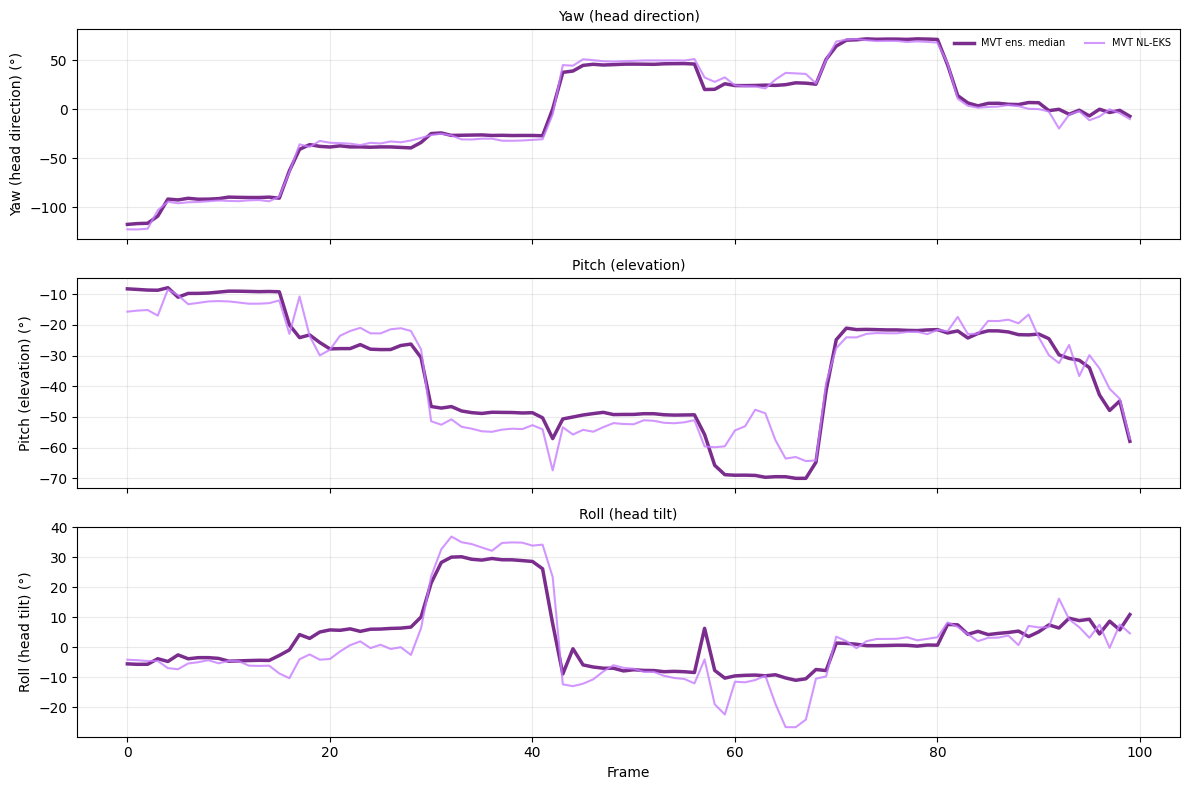

In [12]:
# 8a. Yaw, Pitch, Roll time-series
plot_yaw_pitch_roll(angles, reference_model, dt=dt, use_frames=True, colors=plot_colors)

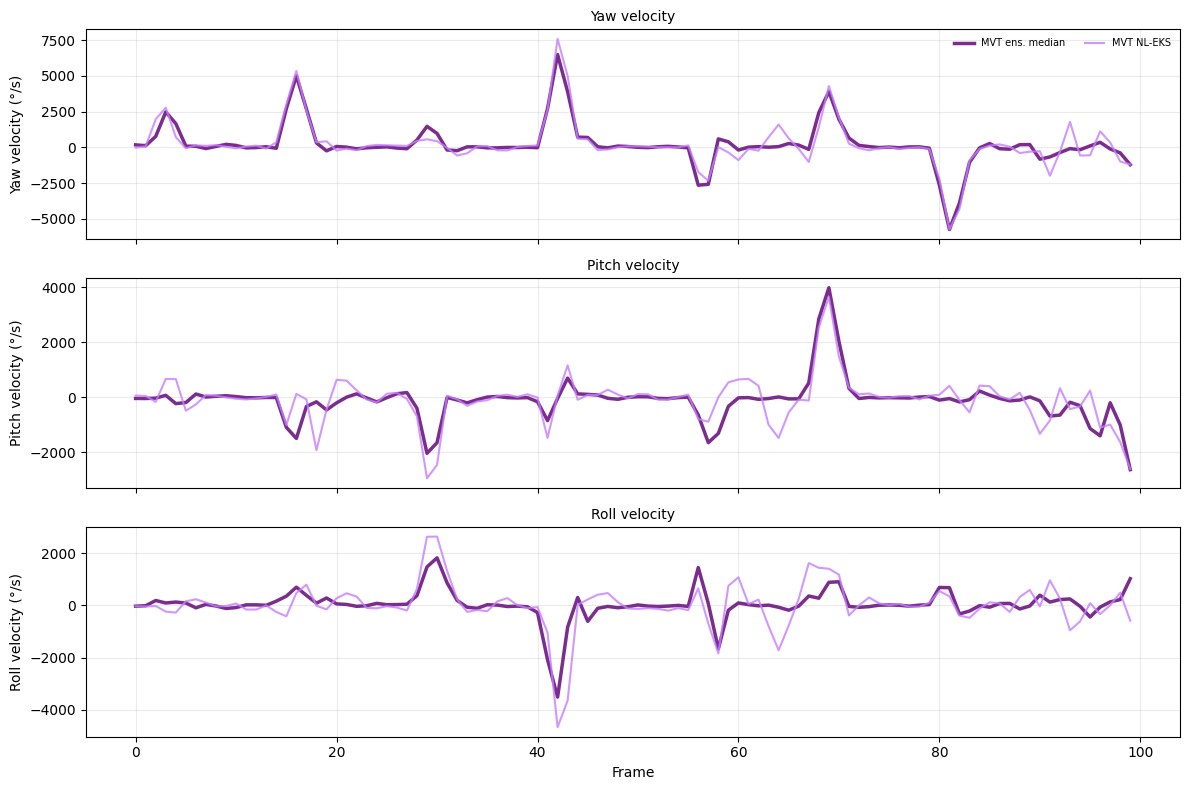

In [13]:
# 8b. Angular velocities
plot_angular_velocities(angles, reference_model, dt=dt, use_frames=True, colors=plot_colors)

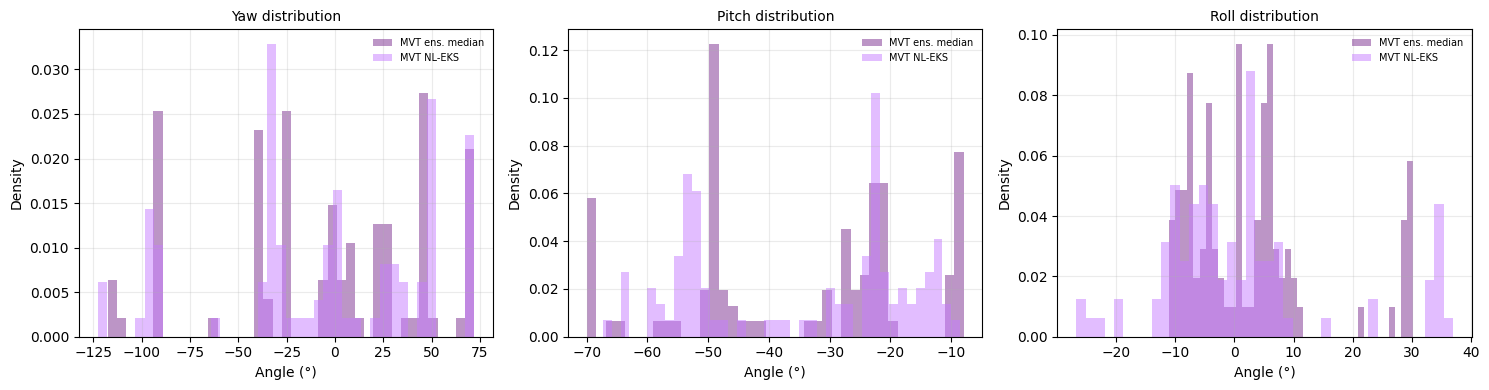

In [14]:
# 8c. Distributions
plot_distributions(angles, colors=plot_colors)

## 9. Summary metrics

In [15]:
print_summary_metrics(angles, dt=dt)

Model                                                   Metric       Mean      Std      Min      Max   |Vel| mean
--------------------------------------------------------------------------------------------------------------
MVT ens. median                                         yaw         -5.85    52.58  -117.65    72.12       706.74
                                                        pitch      -35.08    18.59   -69.96    -7.95       353.58
                                                        roll         2.83    11.19   -11.03    30.20       280.32
MVT NL-EKS                                              yaw         -5.85    54.02  -122.84    71.94       818.13
                                                        pitch      -34.98    17.54   -67.38    -8.48       476.66
                                                        roll         1.10    14.47   -26.69    36.94       486.51


## 10. Head Saccade Detection

Chickadees (and birds in general) move their heads in rapid, discrete **saccades**
separated by stable fixation periods. Detecting saccades is a meaningful way to
compare models — a good model should produce clean, sharp saccade events with
stable fixations in between, while a noisy model will produce spurious velocity
peaks or smear real saccades.

**Algorithm**: Threshold the angular velocity of yaw (the dominant saccade axis)
to find rapid head turns. A saccade is defined as a contiguous period where
|angular velocity| exceeds a threshold, with optional merging of nearby events
and minimum-duration filtering.

In [16]:
def detect_saccades(
    angle_trace,
    dt,
    vel_threshold_deg_s=500,
    min_duration_ms=10,
    merge_gap_ms=20,
    angle_key='yaw',
):
    """
    Detect head saccades from an angular trace.

    Parameters
    ----------
    angle_trace : 1-D array
        Angle values in degrees (e.g. yaw).
    dt : float
        Time step in seconds (1/fps).
    vel_threshold_deg_s : float
        Minimum absolute angular velocity (deg/s) to count as saccade.
    min_duration_ms : float
        Minimum saccade duration in milliseconds.
    merge_gap_ms : float
        Merge saccade segments separated by fewer than this many ms.

    Returns
    -------
    saccades : list of dict
        Each dict has: onset, offset (frame indices), duration_ms,
        amplitude_deg, peak_velocity_deg_s, direction ('CW' or 'CCW').
    velocity : 1-D array
        Angular velocity trace (deg/s).
    is_saccade : bool array
        Per-frame saccade mask.
    """
    velocity = np.gradient(angle_trace, dt)
    abs_vel = np.abs(velocity)

    is_saccade = abs_vel >= vel_threshold_deg_s

    min_frames = max(1, int(np.round(min_duration_ms / 1000.0 / dt)))
    merge_frames = max(0, int(np.round(merge_gap_ms / 1000.0 / dt)))

    # Label contiguous saccade regions
    regions = []
    in_region = False
    for i, val in enumerate(is_saccade):
        if val and not in_region:
            start = i
            in_region = True
        elif not val and in_region:
            regions.append((start, i))
            in_region = False
    if in_region:
        regions.append((start, len(is_saccade)))

    # Merge nearby regions
    if merge_frames > 0 and len(regions) > 1:
        merged = [regions[0]]
        for s, e in regions[1:]:
            if s - merged[-1][1] <= merge_frames:
                merged[-1] = (merged[-1][0], e)
            else:
                merged.append((s, e))
        regions = merged

    # Filter by minimum duration
    regions = [(s, e) for s, e in regions if (e - s) >= min_frames]

    # Rebuild mask
    is_saccade = np.zeros(len(angle_trace), dtype=bool)
    for s, e in regions:
        is_saccade[s:e] = True

    # Extract saccade properties
    saccades = []
    for s, e in regions:
        seg_vel = velocity[s:e]
        amplitude = angle_trace[min(e, len(angle_trace)-1)] - angle_trace[s]
        peak_vel = seg_vel[np.argmax(np.abs(seg_vel))]
        saccades.append({
            'onset': s,
            'offset': e,
            'duration_ms': (e - s) * dt * 1000,
            'amplitude_deg': amplitude,
            'peak_velocity_deg_s': peak_vel,
            'direction': 'CW' if peak_vel > 0 else 'CCW',
        })

    return saccades, velocity, is_saccade


def detect_saccades_all_models(angles, dt, angle_key='yaw', **kwargs):
    """Run saccade detection on all models. Returns dict of results."""
    results = {}
    for model, data in angles.items():
        saccades, vel, mask = detect_saccades(data[angle_key], dt, **kwargs)
        results[model] = {
            'saccades': saccades,
            'velocity': vel,
            'is_saccade': mask,
            'n_saccades': len(saccades),
        }
    return results


def saccade_summary_table(saccade_results, model_names=None):
    """Print a comparison table of saccade statistics across models."""
    if model_names is None:
        model_names = list(saccade_results.keys())

    print(f"{'Model':<40} {'Count':>6} {'Amp (°)':>10} {'Dur (ms)':>10} "
          f"{'Peak vel':>12} {'Fixation %':>12}")
    print("-" * 95)

    for model in model_names:
        r = saccade_results[model]
        sacs = r['saccades']
        n = len(sacs)
        mask = r['is_saccade']
        fix_pct = 100.0 * (1 - mask.mean())

        if n == 0:
            print(f"{model[:39]:<40} {0:>6} {'N/A':>10} {'N/A':>10} {'N/A':>12} {fix_pct:>11.1f}%")
            continue

        amps = [abs(s['amplitude_deg']) for s in sacs]
        durs = [s['duration_ms'] for s in sacs]
        peaks = [abs(s['peak_velocity_deg_s']) for s in sacs]

        print(f"{model[:39]:<40} {n:>6} {np.mean(amps):>9.1f}° {np.mean(durs):>9.1f} "
              f"{np.mean(peaks):>11.0f}°/s {fix_pct:>11.1f}%")

    print()


def plot_saccades_on_trace(angles, saccade_results, reference_model, dt,
                            angle_key='yaw', colors=None):
    """
    Plot the angle trace with saccade events highlighted, plus velocity with threshold.
    """
    models = list(angles.keys())
    n = len(angles[models[0]][angle_key])
    t = np.arange(n) * dt * 1000  # time in ms

    fig, axes = plt.subplots(len(models), 2, figsize=(14, 3.5 * len(models)),
                              squeeze=False, sharex='col')

    for row, model in enumerate(models):
        color = (colors or {}).get(model, f'C{row}')
        trace = angles[model][angle_key]
        r = saccade_results[model]
        vel = r['velocity']
        mask = r['is_saccade']

        # Left: angle trace with saccade shading
        ax = axes[row, 0]
        ax.plot(t, trace, color=color, lw=1.2, alpha=0.9)
        for s in r['saccades']:
            t0 = s['onset'] * dt * 1000
            t1 = s['offset'] * dt * 1000
            ax.axvspan(t0, t1, alpha=0.25, color='red')
        ax.set_ylabel(f'{angle_key.capitalize()} (°)')
        ax.set_title(f'{model}  —  {r["n_saccades"]} saccades', fontsize=9)
        ax.grid(alpha=0.2)

        # Right: velocity with threshold
        ax2 = axes[row, 1]
        ax2.plot(t, vel, color=color, lw=0.8, alpha=0.7)
        ax2.fill_between(t, vel, where=mask, alpha=0.3, color='red')
        ax2.set_ylabel(f'{angle_key.capitalize()} vel (°/s)')
        ax2.set_title(f'Angular velocity', fontsize=9)
        ax2.grid(alpha=0.2)

    axes[-1, 0].set_xlabel('Time (ms)')
    axes[-1, 1].set_xlabel('Time (ms)')
    fig.suptitle(f'Head Saccade Detection — {angle_key.capitalize()}',
                 fontsize=12, fontweight='bold')
    fig.tight_layout()
    plt.show()


def plot_saccade_distributions(saccade_results, colors=None):
    """Plot distributions of saccade amplitude, duration, and peak velocity."""
    models = list(saccade_results.keys())
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    props = [
        ('amplitude_deg', 'Amplitude (°)'),
        ('duration_ms', 'Duration (ms)'),
        ('peak_velocity_deg_s', 'Peak velocity (°/s)'),
    ]

    for ax, (key, label) in zip(axes, props):
        for model in models:
            sacs = saccade_results[model]['saccades']
            if not sacs:
                continue
            vals = [abs(s[key]) for s in sacs]
            color = (colors or {}).get(model, None)
            ax.hist(vals, bins=20, alpha=0.5, label=model, color=color, density=True)
        ax.set_xlabel(label)
        ax.set_ylabel('Density')
        ax.legend(fontsize=7, frameon=False)
        ax.grid(alpha=0.2)

    fig.suptitle('Saccade Property Distributions', fontsize=12, fontweight='bold')
    fig.tight_layout()
    plt.show()

### 10a. Saccade detection parameters

Adjust the threshold and timing parameters below. At 200 Hz:
- A typical chickadee saccade lasts ~15-50 ms (3-10 frames)
- Peak angular velocities during saccades are typically 500-3000+ °/s
- Fixation periods have velocities well below 200 °/s

In [17]:
# Saccade detection parameters
saccade_params = dict(
    vel_threshold_deg_s=500,   # minimum angular velocity to count as saccade
    min_duration_ms=10,        # minimum saccade duration
    merge_gap_ms=20,           # merge saccade segments closer than this
)

# Which angle to use for saccade detection (yaw is the primary saccade axis for birds)
saccade_angle = 'yaw'

# Detect saccades for all models
saccade_results = detect_saccades_all_models(
    angles, dt, angle_key=saccade_angle, **saccade_params
)

print(f"Saccade detection on '{saccade_angle}' (threshold={saccade_params['vel_threshold_deg_s']}°/s)\n")
saccade_summary_table(saccade_results)

Saccade detection on 'yaw' (threshold=500°/s)

Model                                     Count    Amp (°)   Dur (ms)     Peak vel   Fixation %
-----------------------------------------------------------------------------------------------
MVT ens. median                               8      38.4°      16.9        3568°/s        73.0%
MVT NL-EKS                                    7      36.2°      30.7        4041°/s        57.0%



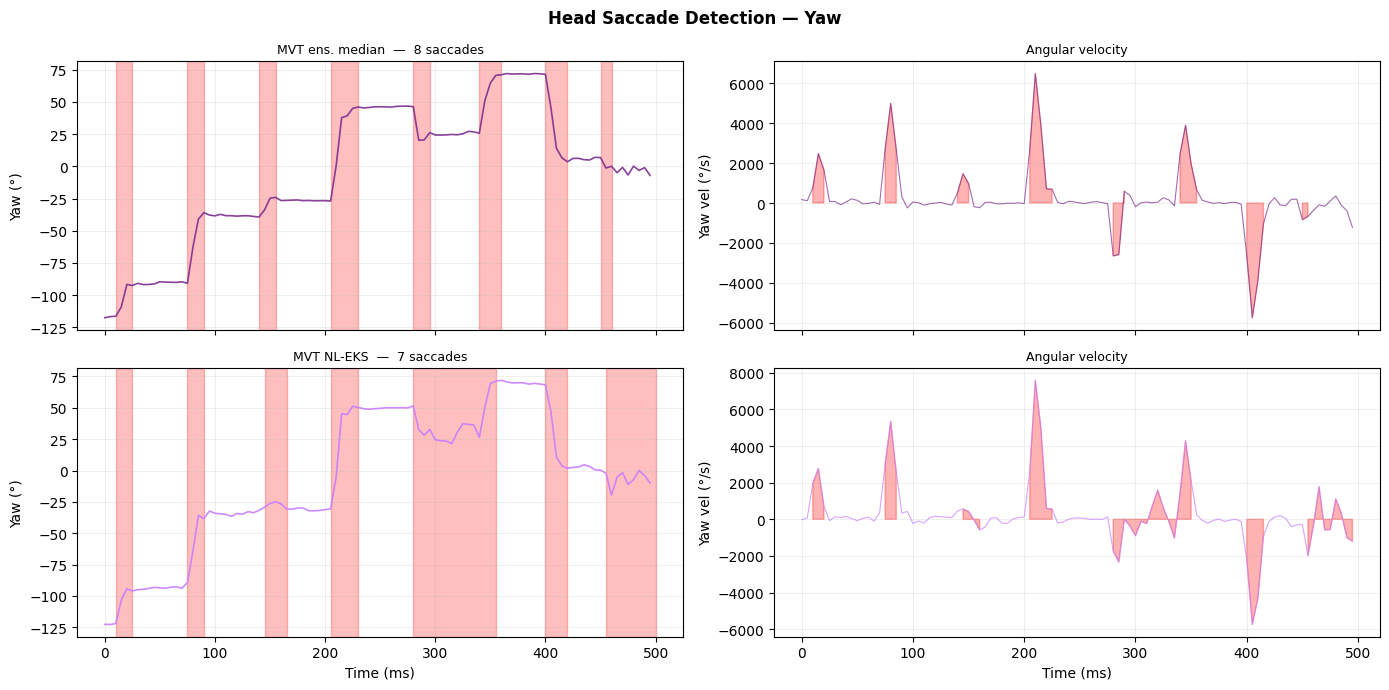

In [18]:
# Visualise saccades on the yaw trace + velocity
plot_saccades_on_trace(angles, saccade_results, reference_model, dt,
                       angle_key=saccade_angle, colors=plot_colors)

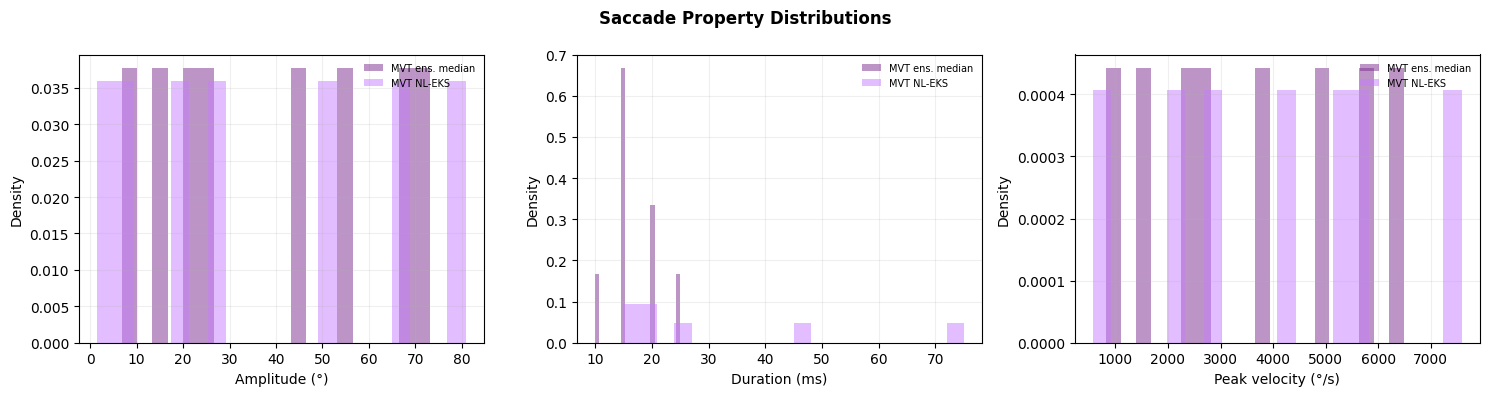

In [19]:
# Saccade property distributions
plot_saccade_distributions(saccade_results, colors=plot_colors)

Pitch saccades:

Model                                     Count    Amp (°)   Dur (ms)     Peak vel   Fixation %
-----------------------------------------------------------------------------------------------
MVT ens. median                               6      22.2°      19.2        2102°/s        77.0%
MVT NL-EKS                                    6      18.1°      33.3        2208°/s        60.0%



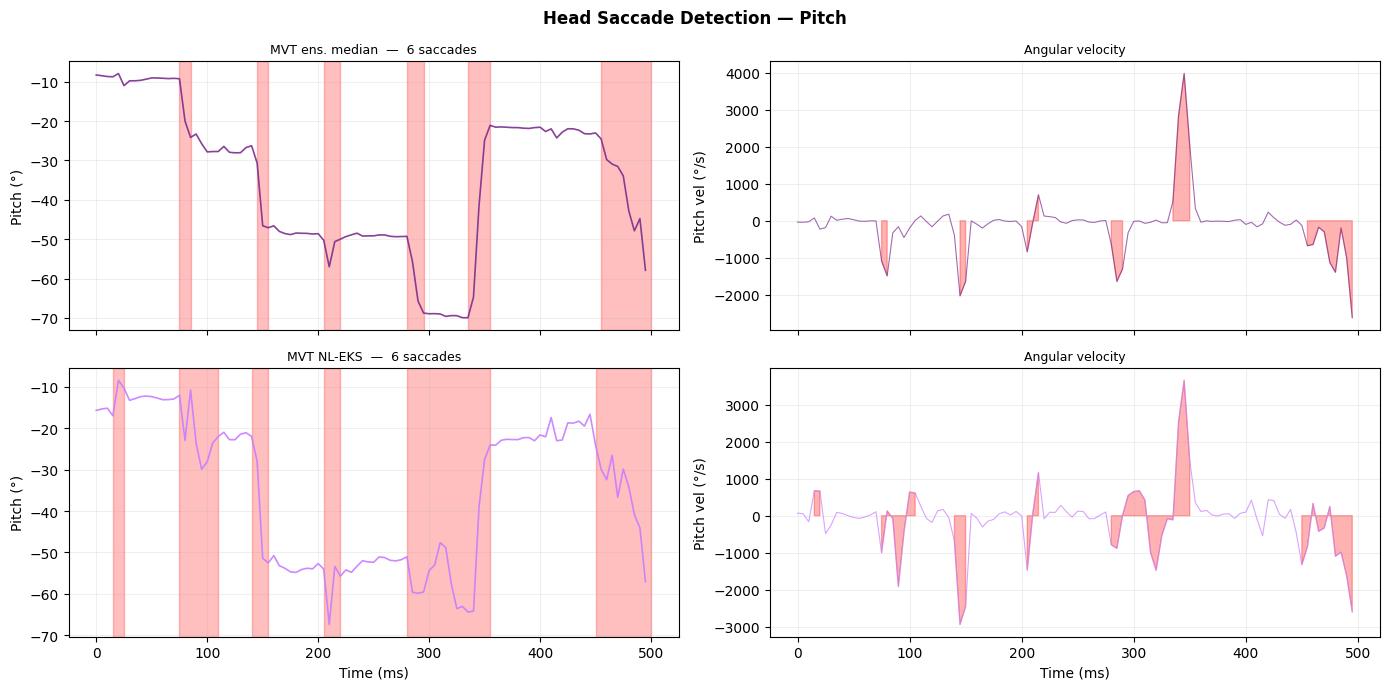

In [20]:
# Also detect saccades on pitch
print("Pitch saccades:\n")
saccade_results_pitch = detect_saccades_all_models(
    angles, dt, angle_key='pitch', **saccade_params
)
saccade_summary_table(saccade_results_pitch)

plot_saccades_on_trace(angles, saccade_results_pitch, reference_model, dt,
                       angle_key='pitch', colors=plot_colors)

### 10b. Cross-model saccade agreement

If two models detect a saccade at the same time, it's likely a real saccade.
Saccades detected by only one model may be noise artifacts. This gives us a
**reference-free** way to evaluate model quality.

Cross-model saccade agreement (tolerance = 3 frames)

Model                                     Total   In consensus   Unique  Agreement %
-------------------------------------------------------------------------------------
MVT ens. median                               8              7        1        87.5%
MVT NL-EKS                                    7              7        0       100.0%

Consensus saccades (detected by ≥2 models): 9


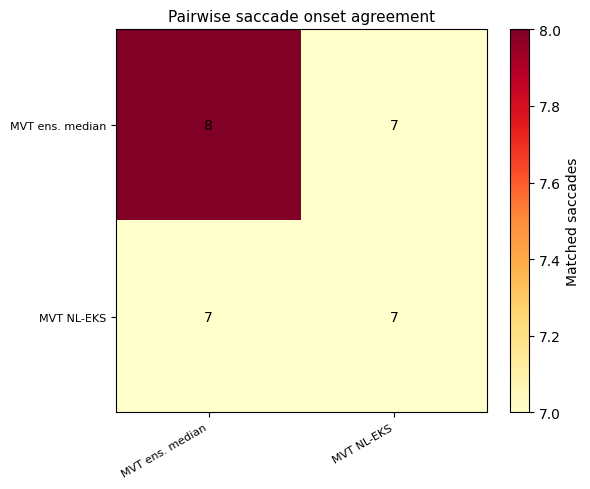

In [21]:
def compute_saccade_agreement(saccade_results, tolerance_frames=3):
    """
    Compute pairwise saccade onset agreement between models.
    Two saccades "agree" if their onsets are within tolerance_frames of each other.
    """
    models = list(saccade_results.keys())
    n_models = len(models)
    agreement = np.zeros((n_models, n_models))
    unique_to = {m: 0 for m in models}

    for i, m1 in enumerate(models):
        onsets1 = [s['onset'] for s in saccade_results[m1]['saccades']]
        for j, m2 in enumerate(models):
            if i == j:
                agreement[i, j] = len(onsets1)
                continue
            onsets2 = [s['onset'] for s in saccade_results[m2]['saccades']]
            matched = 0
            for o1 in onsets1:
                if any(abs(o1 - o2) <= tolerance_frames for o2 in onsets2):
                    matched += 1
            agreement[i, j] = matched

    # Consensus saccades: detected by majority of models
    all_onsets = []
    for m in models:
        for s in saccade_results[m]['saccades']:
            all_onsets.append(s['onset'])
    all_onsets = sorted(set(all_onsets))

    consensus = []
    for onset in all_onsets:
        n_agree = sum(
            1 for m in models
            if any(abs(onset - s['onset']) <= tolerance_frames
                   for s in saccade_results[m]['saccades'])
        )
        if n_agree >= max(2, n_models // 2):
            consensus.append(onset)

    # Per-model: how many of its saccades are in consensus
    print(f"Cross-model saccade agreement (tolerance = {tolerance_frames} frames)\n")
    print(f"{'Model':<40} {'Total':>6} {'In consensus':>14} {'Unique':>8} {'Agreement %':>12}")
    print("-" * 85)
    for m in models:
        total = len(saccade_results[m]['saccades'])
        in_cons = sum(
            1 for s in saccade_results[m]['saccades']
            if any(abs(s['onset'] - c) <= tolerance_frames for c in consensus)
        )
        unique = total - in_cons
        pct = 100 * in_cons / total if total > 0 else 0
        print(f"{m[:39]:<40} {total:>6} {in_cons:>14} {unique:>8} {pct:>11.1f}%")

    print(f"\nConsensus saccades (detected by ≥{max(2, n_models//2)} models): {len(consensus)}")

    # Pairwise agreement matrix
    fig, ax = plt.subplots(figsize=(6, 5))
    short_names = [m[:20] for m in models]
    im = ax.imshow(agreement, cmap='YlOrRd', aspect='auto')
    ax.set_xticks(range(n_models))
    ax.set_yticks(range(n_models))
    ax.set_xticklabels(short_names, rotation=30, ha='right', fontsize=8)
    ax.set_yticklabels(short_names, fontsize=8)
    for i in range(n_models):
        for j in range(n_models):
            ax.text(j, i, f'{int(agreement[i,j])}', ha='center', va='center', fontsize=10)
    ax.set_title('Pairwise saccade onset agreement', fontsize=11)
    plt.colorbar(im, ax=ax, label='Matched saccades')
    fig.tight_layout()
    plt.show()

    return consensus

consensus_saccades = compute_saccade_agreement(saccade_results, tolerance_frames=3)

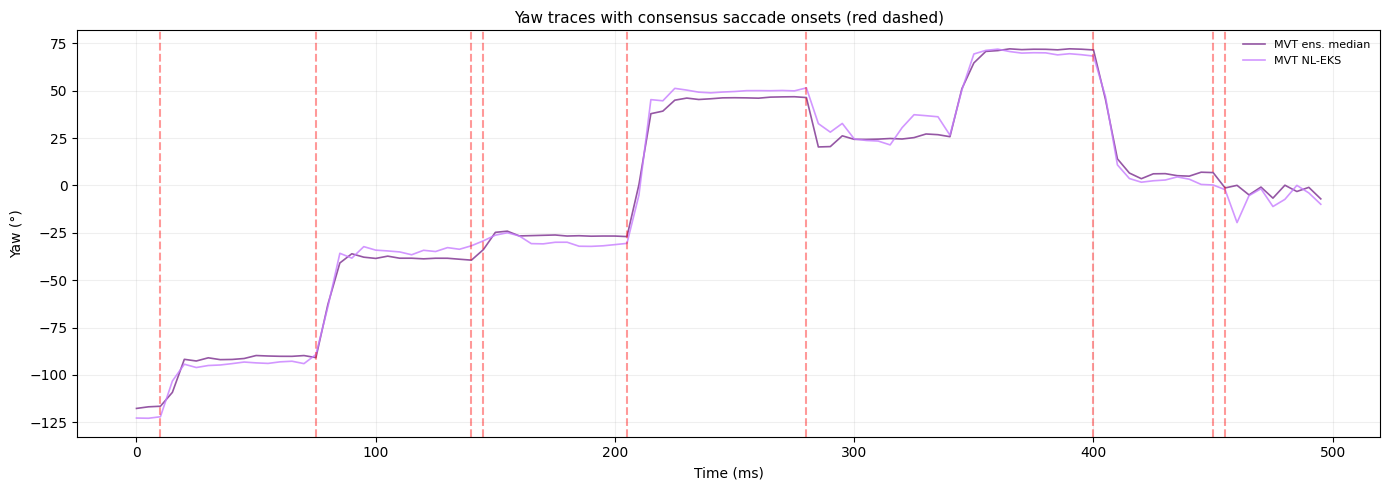


Consensus saccade onset times (ms): [10.0, 75.0, 140.0, 145.0, 205.0, 280.0, 400.0, 450.0, 455.0]


In [22]:
# Overlay all models on a single yaw trace with saccade markers
fig, ax = plt.subplots(figsize=(14, 5))
models = list(angles.keys())
n = len(angles[models[0]]['yaw'])
t = np.arange(n) * dt * 1000  # ms

for model in models:
    color = plot_colors.get(model, None)
    ax.plot(t, angles[model]['yaw'], lw=1.2, alpha=0.8, color=color, label=model)

# Mark consensus saccades
for onset in consensus_saccades:
    t_onset = onset * dt * 1000
    ax.axvline(t_onset, color='red', alpha=0.4, lw=1.5, ls='--')

ax.set_xlabel('Time (ms)')
ax.set_ylabel('Yaw (°)')
ax.set_title('Yaw traces with consensus saccade onsets (red dashed)', fontsize=11)
ax.legend(fontsize=8, frameon=False)
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

print(f"\nConsensus saccade onset times (ms): "
      f"{[round(o * dt * 1000, 1) for o in consensus_saccades]}")

## 11. 3D Evaluation — MVT vs Supervised

Two unbiased metrics that measure true 3D quality without favoring methods
that explicitly optimize for multi-view consistency:

1. **Leave-one-view-out (LOO) reprojection error**: Triangulate from 5 views,
   measure 2D error on the held-out 6th view. Lower = better cross-view consistency.
2. **3D error vs ground truth**: Triangulate hand-labeled OOD frames to get
   pseudo-GT 3D, triangulate model predictions on the same frames, measure
   3D Euclidean distance. Lower = more accurate 3D reconstruction.

In [23]:
ALL_KEYPOINTS = ['topBeak', 'botBeak', 'topHead', 'backHead', 'centerChes', 'centerBack',
                 'baseTail', 'tipTail', 'leftEye', 'leftNeck', 'leftWing', 'leftAnkle',
                 'leftFoot', 'rightEye', 'rightNeck', 'rightWing', 'rightAnkle', 'rightFoot']
HEAD_IDXS_IN_ALL = [ALL_KEYPOINTS.index(k) for k in HEAD_KEYS]


def leave_one_view_out_error(model_dirs, views, camera_group, n_frames=500,
                              session='PRL43_200701_142147'):
    """
    Compute leave-one-view-out reprojection error for each model.
    Triangulate from 5 views, measure 2D error on held-out 6th view.
    """
    results = []
    for model_name, model_dir in model_dirs.items():
        pts2d_all = []
        for v in views:
            fp = os.path.join(model_dir, f'{session}_{v}.short_uncropped.csv')
            if not os.path.exists(fp):
                break
            df = pd.read_csv(fp, header=[0, 1, 2], index_col=0).iloc[:n_frames]
            x = df.loc[:, df.columns.get_level_values(2) == 'x'].values
            y = df.loc[:, df.columns.get_level_values(2) == 'y'].values
            pts2d_all.append(np.stack([x, y], axis=-1))
        if len(pts2d_all) != len(views):
            continue
        pts2d_all = np.array(pts2d_all)
        nf = pts2d_all.shape[1]

        loo_head, loo_all = [], []
        for held_out in range(len(views)):
            for fi in range(nf):
                frame = pts2d_all[:, fi, :, :].copy()
                actual = frame[held_out].copy()
                frame[held_out] = np.nan
                kp3d = camera_group.triangulate(frame, fast=True)
                reproj = camera_group.project(kp3d)
                err = np.sqrt(np.sum((reproj[held_out] - actual) ** 2, axis=1))
                loo_head.append(err[HEAD_IDXS_IN_ALL].mean())
                loo_all.append(err.mean())

        results.append({
            'model': model_name,
            'loo_head_px': np.mean(loo_head),
            'loo_all_px': np.mean(loo_all),
            'n_frames': nf,
        })
    return pd.DataFrame(results)


def compute_3d_error_vs_gt(gt_data, bbox_data, views, results_configs_3d,
                            seed_dirs, camera_params_dir, kp_names, head_keys):
    """
    Triangulate GT labels and model predictions on OOD frames,
    compute 3D Euclidean distance.
    """
    head_idxs = [kp_names.index(k) for k in head_keys]

    sessions_frames = {}
    for view in views:
        for idx in gt_data[view].index:
            parts = idx.split('/')
            sess = parts[1].replace(f'_{view}', '')
            fid = parts[2]
            sessions_frames.setdefault(sess, {}).setdefault(fid, set()).add(view)
    common = {}
    for sess, frames in sessions_frames.items():
        for fid, pv in frames.items():
            if len(pv) == len(views):
                common.setdefault(sess, []).append(fid)
    for s in common:
        common[s] = sorted(common[s])

    def uncrop(x_crop, y_crop, bbox_row):
        bx, by = bbox_row['x'], bbox_row['y']
        bw, bh = bbox_row['w'], bbox_row['h']
        return x_crop * (bw / 320.0) + bx, y_crop * (bh / 320.0) + by

    def tri_frames(data_dict, bbox_dict, cg, sess, fids, kp_names):
        pts3d, valid = [], []
        for fid in fids:
            pts2d_views = []
            for view in views:
                full_idx = f"labeled-data/{sess}_{view}/{fid}"
                if full_idx not in data_dict[view].index or full_idx not in bbox_dict[view].index:
                    pts2d_views.append(np.full((len(kp_names), 2), np.nan))
                    continue
                row = data_dict[view].loc[full_idx]
                x_c = np.array([row.xs(kp, level=1).xs('x', level=1).values[0] for kp in kp_names])
                y_c = np.array([row.xs(kp, level=1).xs('y', level=1).values[0] for kp in kp_names])
                x_o, y_o = uncrop(x_c, y_c, bbox_dict[view].loc[full_idx])
                pts2d_views.append(np.column_stack([x_o, y_o]))
            pts2d = np.stack(pts2d_views)
            n_valid = (~np.isnan(pts2d).any(axis=2)).all(axis=1).sum()
            if n_valid >= 2:
                pts2d_c = pts2d.copy()
                pts2d_c[np.isnan(pts2d_c)] = 0
                try:
                    pts3d.append(cg.triangulate(pts2d_c, fast=True))
                    valid.append(fid)
                except:
                    pass
        return (np.stack(pts3d), valid) if pts3d else (np.empty((0, len(kp_names), 3)), [])

    all_results = []
    for sess, fids in common.items():
        cam_path = Path(camera_params_dir) / f'{sess}.toml'
        if not cam_path.exists():
            continue
        cg = CameraGroup.load(str(cam_path))
        gt_3d, valid_fids = tri_frames(gt_data, bbox_data, cg, sess, fids, kp_names)
        if gt_3d.shape[0] == 0:
            continue

        for model_name, (results_dir, model_type) in results_configs_3d.items():
            for seed in seed_dirs:
                pred_data = {}
                for view in views:
                    pp = os.path.join(
                        '/teamspace/studios/this_studio/outputs/chickadee-crop',
                        results_dir, f'{model_type}_200_{seed}',
                        'image_preds', f'CollectedData_{view}_new.csv', 'predictions.csv')
                    if os.path.exists(pp):
                        pred_data[view] = pd.read_csv(pp, header=[0, 1, 2], index_col=0)
                if len(pred_data) < len(views):
                    continue
                pred_3d, _ = tri_frames(pred_data, bbox_data, cg, sess, valid_fids, kp_names)
                if pred_3d.shape[0] == 0:
                    continue
                n = min(gt_3d.shape[0], pred_3d.shape[0])
                err_3d = np.linalg.norm(gt_3d[:n, head_idxs] - pred_3d[:n, head_idxs], axis=-1) * 1000
                err_all = np.linalg.norm(gt_3d[:n] - pred_3d[:n], axis=-1) * 1000
                all_results.append({
                    'session': sess, 'model': model_name, 'seed': seed,
                    'head_3d_err_mm': np.nanmean(err_3d),
                    'all_3d_err_mm': np.nanmean(err_all),
                    'n_frames': n,
                })
    return pd.DataFrame(all_results)

### 11a. Leave-one-view-out reprojection error

In [24]:
loo_n_frames = 500

loo_model_dirs = {}
for model_key, config in results_configs.items():
    mt = config['model_type']
    for ens_method in ensemble_methods:
        ens_dir = os.path.join(
            '/teamspace/studios/this_studio/outputs/chickadee-crop',
            model_key, f"{mt}_200_{ensemble_seed}", ens_method, video_dir)
        if os.path.exists(ens_dir):
            label = f"{model_key.replace('test_200_', '')}_{ens_method}"
            loo_model_dirs[label] = ens_dir

print(f"Running LOO on {len(loo_model_dirs)} model variants ({loo_n_frames} frames)...\n")
loo_df = leave_one_view_out_error(
    loo_model_dirs, views, camera_group, n_frames=loo_n_frames,
    session=original_session_name,
)

loo_df['type'] = loo_df['model'].apply(
    lambda x: 'MVT' if 'MVT' in x else 'SV_ViTs')

print("Leave-one-view-out reprojection error (px)")
print("=" * 70)
print(loo_df[['model', 'loo_head_px', 'loo_all_px']].to_string(index=False))

Running LOO on 2 model variants (500 frames)...

Leave-one-view-out reprojection error (px)
                                              model  loo_head_px   loo_all_px
      MVT_3d_loss_patch_masking_new_ensemble_median 5.995169e+00 6.915352e+00
MVT_3d_loss_patch_masking_new_non_linear_eks_varinf 4.958058e-09 2.825300e-09


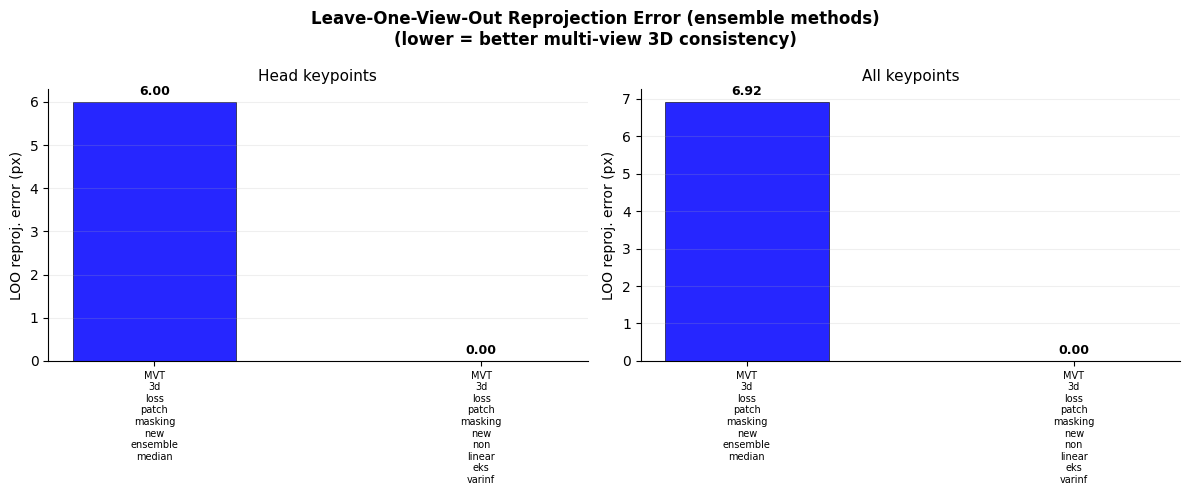

In [25]:
model_colors_loo = {'MVT': 'blue', 'SV_ViTs': 'orange', 'MVT_NL-EKS': 'green'}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, title in zip(axes,
    ['loo_head_px', 'loo_all_px'],
    ['Head keypoints', 'All keypoints']):

    vals = []
    labels = []
    bar_cols = []
    for _, row in loo_df.iterrows():
        vals.append(row[col])
        labels.append(row['model'])
        bar_cols.append(model_colors_loo.get(row['type'], 'gray'))

    x_pos = np.arange(len(vals))
    bars = ax.bar(x_pos, vals, color=bar_cols,
                  alpha=0.85, edgecolor='black', linewidth=0.5, width=0.5)

    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_xticks(x_pos)
    ax.set_xticklabels([m.replace('_', '\n') for m in labels], fontsize=7)
    ax.set_ylabel('LOO reproj. error (px)')
    ax.set_title(f'{title}', fontsize=11)
    ax.grid(alpha=0.2, axis='y')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
save_path = '/teamspace/studios/this_studio/outputs/chickadee-crop/plots/head_direction_plots/loo_reproj_error.pdf'
fig.suptitle('Leave-One-View-Out Reprojection Error (ensemble methods)\n(lower = better multi-view 3D consistency)',
             fontsize=12, fontweight='bold')
fig.tight_layout()
fig.savefig(save_path, bbox_inches='tight', dpi=300)
plt.show()

### 11b. 3D error vs ground truth (OOD frames)

In [ ]:
data_dir_3d = f'/teamspace/studios/data/{dataset_name}'

gt_data_3d = {}
bbox_data_3d = {}
for v in views:
    gt_data_3d[v] = pd.read_csv(os.path.join(data_dir_3d, f'CollectedData_{v}_new.csv'),
                                 header=[0, 1, 2], index_col=0)
    bbox_data_3d[v] = pd.read_csv(os.path.join(data_dir_3d, f'bboxes_{v}_new.csv'), index_col=0)

results_configs_3d = {}
for model_key, config in results_configs.items():
    results_configs_3d[model_key.replace('test_200_', '')] = (model_key, config['model_type'])

err3d_df = compute_3d_error_vs_gt(
    gt_data_3d, bbox_data_3d, views, results_configs_3d,
    seed_dirs, camera_params_dir, ALL_KEYPOINTS, HEAD_KEYS,
)

if len(err3d_df) > 0:
    err3d_df['type'] = err3d_df['model'].apply(lambda x: 'MVT' if 'MVT' in x else 'SV_ViTs')

    print("3D error vs ground truth (mm) — head keypoints")
    print("=" * 60)
    for mt in err3d_df['type'].unique():
        sub = err3d_df[err3d_df['type'] == mt]
        print(f"  {mt:20s}: head = {sub['head_3d_err_mm'].mean():.2f} ± {sub['head_3d_err_mm'].std():.2f} mm, "
              f"all = {sub['all_3d_err_mm'].mean():.2f} ± {sub['all_3d_err_mm'].std():.2f} mm")

    print("\nPer-seed breakdown:")
    for _, row in err3d_df.groupby(['model', 'seed']).agg(
        head=('head_3d_err_mm', 'mean'), all_kp=('all_3d_err_mm', 'mean')
    ).reset_index().iterrows():
        print(f"  {row['model']}_seed_{row['seed']}: head={row['head']:.2f} mm, all={row['all_kp']:.2f} mm")
else:
    print("No OOD frames available for 3D error computation.")

3D error vs ground truth (mm) — head keypoints
  MVT                 : head = 4.27 ± 0.19 mm, all = 5.93 ± 0.71 mm
  SV_ViTs             : head = 4.07 ± 0.17 mm, all = 5.83 ± 0.54 mm

Per-seed breakdown:
  MVT_3d_loss_patch_masking_new_seed_0: head=4.24 mm, all=5.87 mm
  MVT_3d_loss_patch_masking_new_seed_1: head=4.34 mm, all=6.03 mm
  MVT_3d_loss_patch_masking_new_seed_2: head=4.23 mm, all=5.89 mm
  SV_vits_dino_seed_0: head=4.09 mm, all=5.78 mm
  SV_vits_dino_seed_1: head=4.09 mm, all=5.84 mm
  SV_vits_dino_seed_2: head=4.03 mm, all=5.86 mm


### 11c. Combined summary — LOO vs 3D error

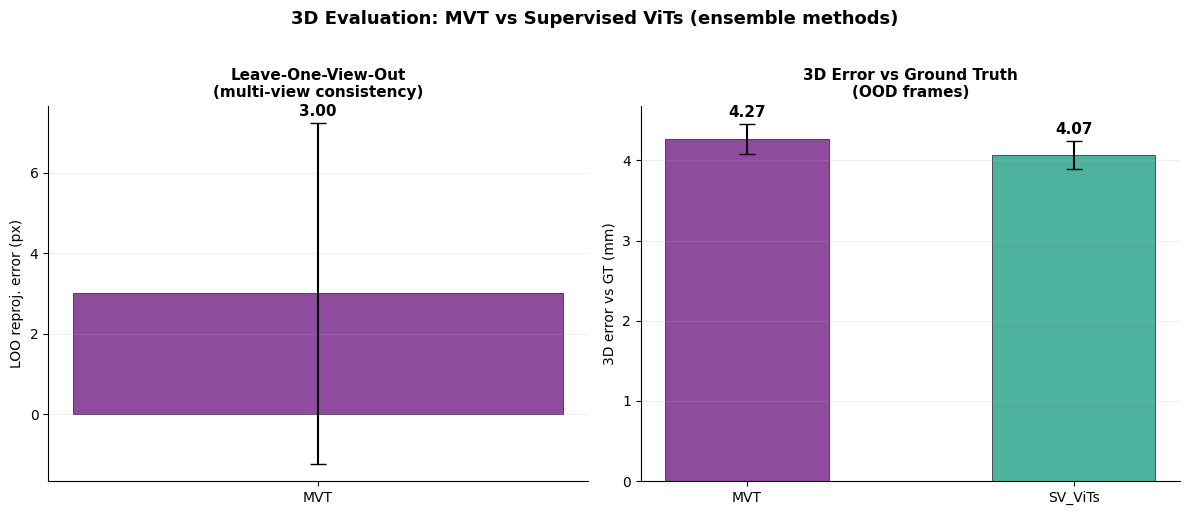


INTERPRETATION
LOO: SV_ViTs has nan% lower LOO error -> better multi-view consistency
3D:  SV_ViTs has 4.9% lower 3D error -> more accurate 3D reconstruction


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

model_colors = {'MVT': '#7B2D8E', 'SV_ViTs': '#2CA58D', 'MVT_NL-EKS': '#FFD700'}

# Panel 1: LOO reprojection error
ax = axes[0]
loo_grouped = loo_df.groupby('type')['loo_head_px']
means_loo = loo_grouped.mean()
stds_loo = loo_grouped.std().fillna(0)
x_pos = np.arange(len(means_loo))
for xi, mt in enumerate(means_loo.index):
    ax.bar(xi, means_loo[mt], yerr=stds_loo[mt], color=model_colors.get(mt, 'gray'),
           alpha=0.85, capsize=6, edgecolor='black', linewidth=0.5, width=0.5)
    ax.text(xi, means_loo[mt] + stds_loo[mt] + 0.1, f'{means_loo[mt]:.2f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(means_loo.index, fontsize=10)
ax.set_ylabel('LOO reproj. error (px)', fontsize=10)
ax.set_title('Leave-One-View-Out\n(multi-view consistency)', fontsize=11, fontweight='bold')
ax.grid(alpha=0.2, axis='y')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Panel 2: 3D error vs GT
ax = axes[1]
if len(err3d_df) > 0:
    err3d_grouped = err3d_df.groupby('type')['head_3d_err_mm']
    means_3d = err3d_grouped.mean()
    stds_3d = err3d_grouped.std().fillna(0)
    x_pos = np.arange(len(means_3d))
    for xi, mt in enumerate(means_3d.index):
        ax.bar(xi, means_3d[mt], yerr=stds_3d[mt], color=model_colors.get(mt, 'gray'),
               alpha=0.85, capsize=6, edgecolor='black', linewidth=0.5, width=0.5)
        ax.text(xi, means_3d[mt] + stds_3d[mt] + 0.05, f'{means_3d[mt]:.2f}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(means_3d.index, fontsize=10)
    ax.set_ylabel('3D error vs GT (mm)', fontsize=10)
    ax.set_title('3D Error vs Ground Truth\n(OOD frames)', fontsize=11, fontweight='bold')
    ax.grid(alpha=0.2, axis='y')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
else:
    ax.text(0.5, 0.5, 'No OOD data', ha='center', va='center', transform=ax.transAxes)

fig.suptitle('3D Evaluation: MVT vs Supervised ViTs (ensemble methods)', fontsize=13, fontweight='bold', y=1.02)
fig.tight_layout()
plt.show()

# Print interpretation
print("\n" + "=" * 60)
print("INTERPRETATION")
print("=" * 60)
if len(loo_df) > 0:
    loo_mvt = loo_df[loo_df['type'] == 'MVT']['loo_head_px'].mean()
    loo_sv = loo_df[loo_df['type'] == 'SV_ViTs']['loo_head_px'].mean()
    pct = (loo_sv - loo_mvt) / loo_sv * 100
    if pct > 0:
        print(f"LOO: MVT has {pct:.1f}% lower LOO error -> better multi-view consistency")
    else:
        print(f"LOO: SV_ViTs has {-pct:.1f}% lower LOO error -> better multi-view consistency")

if len(err3d_df) > 0:
    err3d_mvt = err3d_df[err3d_df['type'] == 'MVT']['head_3d_err_mm'].mean()
    err3d_sv = err3d_df[err3d_df['type'] == 'SV_ViTs']['head_3d_err_mm'].mean()
    pct3d = (err3d_sv - err3d_mvt) / err3d_sv * 100
    if pct3d > 0:
        print(f"3D:  MVT has {pct3d:.1f}% lower 3D error -> more accurate 3D reconstruction")
    else:
        print(f"3D:  SV_ViTs has {-pct3d:.1f}% lower 3D error -> more accurate 3D reconstruction")

## 12. Angular Error vs Ground Truth (OOD frames)

Models compared (ensemble methods only):
- **MVT ensemble median** (from `_new` model)
- **MVT NL-EKS** (non-linear Ensemble Kalman Smoother)
- **SV_ViTs ensemble median**

In [28]:
def compute_ood_angular_errors_v2(data_dir, views, camera_params_dir,
                                   head_keys, all_keypoints, base_output_dir,
                                   mvt_results_dir, sv_results_dir, sv_model_type,
                                   seed_dirs):
    kp_idx = {k: i for i, k in enumerate(head_keys)}
    hidx = [all_keypoints.index(k) for k in head_keys]

    gt_d, bbox_d = {}, {}
    for v in views:
        gt_d[v] = pd.read_csv(os.path.join(data_dir, f'CollectedData_{v}_new.csv'),
                               header=[0,1,2], index_col=0)
        bbox_d[v] = pd.read_csv(os.path.join(data_dir, f'bboxes_{v}_new.csv'), index_col=0)

    sf = {}
    for v in views:
        for idx in gt_d[v].index:
            parts = idx.split('/')
            sess = parts[1].replace(f'_{v}', '')
            fid = parts[2]
            sf.setdefault(sess, {}).setdefault(fid, set()).add(v)
    common = {}
    for sess, frames in sf.items():
        for fid, pv in frames.items():
            if len(pv) == len(views):
                common.setdefault(sess, []).append(fid)
    for s in common:
        common[s] = sorted(common[s])

    def _unc(xc, yc, br):
        return xc * (br['w'] / 320.0) + br['x'], yc * (br['h'] / 320.0) + br['y']

    def _tri_dicts(dd, bd, cg, sess, fids):
        p3, vl = [], []
        for fid in fids:
            p2 = []
            for v in views:
                fi = f'labeled-data/{sess}_{v}/{fid}'
                if fi not in dd[v].index or fi not in bd[v].index:
                    p2.append(np.full((len(all_keypoints), 2), np.nan))
                    continue
                row = dd[v].loc[fi]
                xc = np.array([row.xs(k, level=1).xs('x', level=1).values[0] for k in all_keypoints])
                yc = np.array([row.xs(k, level=1).xs('y', level=1).values[0] for k in all_keypoints])
                xo, yo = _unc(xc, yc, bd[v].loc[fi])
                p2.append(np.column_stack([xo, yo]))
            p2 = np.stack(p2)
            p2c = p2.copy()
            p2c[np.isnan(p2c)] = 0
            try:
                p3.append(cg.triangulate(p2c, fast=True))
                vl.append(fid)
            except:
                pass
        return (np.stack(p3), vl) if p3 else (np.empty((0, len(all_keypoints), 3)), [])

    def _tri_pf(mdir, bd, cg, sess, fids, uncropped=False):
        p3, vl = [], []
        for fid in fids:
            p2 = []
            for v in views:
                vd = os.path.join(mdir, 'videos-for-each-labeled-frame', f'{sess}_{v}')
                stem = fid.replace('.png', '')
                fp = os.path.join(vd, stem + ('_uncropped.csv' if uncropped else '.csv'))
                if not os.path.exists(fp):
                    p2.append(np.full((len(all_keypoints), 2), np.nan))
                    continue
                df = pd.read_csv(fp, header=[0,1,2], index_col=0)
                if len(df) == 0:
                    p2.append(np.full((len(all_keypoints), 2), np.nan))
                    continue
                row = df.iloc[len(df) // 2]
                xs, ys = [], []
                for k in all_keypoints:
                    try:
                        xs.append(row.xs(k, level=1).xs('x', level=1).values[0])
                        ys.append(row.xs(k, level=1).xs('y', level=1).values[0])
                    except:
                        xs.append(np.nan)
                        ys.append(np.nan)
                xa, ya = np.array(xs, dtype=float), np.array(ys, dtype=float)
                if not uncropped:
                    fi2 = f'labeled-data/{sess}_{v}/{fid}'
                    if fi2 in bd[v].index:
                        xa, ya = _unc(xa, ya, bd[v].loc[fi2])
                    else:
                        p2.append(np.full((len(all_keypoints), 2), np.nan))
                        continue
                p2.append(np.column_stack([xa, ya]))
            p2 = np.stack(p2)
            p2c = p2.copy()
            p2c[np.isnan(p2c)] = 0
            try:
                p3.append(cg.triangulate(p2c, fast=True))
                vl.append(fid)
            except:
                pass
        return (np.stack(p3), vl) if p3 else (np.empty((0, len(all_keypoints), 3)), [])

    def _angles(h3d):
        em = (h3d[:, kp_idx['leftEye']] + h3d[:, kp_idx['rightEye']]) / 2
        bm = (h3d[:, kp_idx['topBeak']] + h3d[:, kp_idx['botBeak']]) / 2
        fw = bm - em
        fw /= (np.linalg.norm(fw, axis=1, keepdims=True) + 1e-9)
        la = h3d[:, kp_idx['rightEye']] - h3d[:, kp_idx['leftEye']]
        la /= (np.linalg.norm(la, axis=1, keepdims=True) + 1e-9)
        yaw = np.degrees(np.arctan2(fw[:, 1], fw[:, 0]))
        pitch = np.degrees(np.arcsin(np.clip(fw[:, 2], -1, 1)))
        n = len(fw)
        roll = np.zeros(n)
        for i in range(n):
            f, l = fw[i], la[i]
            lp = l - np.dot(l, f) * f
            nm = np.linalg.norm(lp)
            if nm < 1e-9:
                roll[i] = np.nan
                continue
            lp /= nm
            wu = np.array([0., 0., 1.])
            up = wu - np.dot(wu, f) * f
            un = np.linalg.norm(up)
            if un < 1e-9:
                roll[i] = np.nan
                continue
            up /= un
            ri = np.cross(f, up)
            roll[i] = np.degrees(np.arctan2(np.dot(lp, up), np.dot(lp, ri)))
        return yaw, pitch, roll

    def _cerr(a, b):
        return np.abs(((a - b + 180) % 360) - 180)

    mvt_ens_dir = os.path.join(base_output_dir, mvt_results_dir, 'ensemble_median')
    mvt_eks_dir = os.path.join(base_output_dir, mvt_results_dir, 'non_linear_eks_varinf')

    model_cfgs = {
        'MVT ens. median': ('per_frame', mvt_ens_dir, False),
        'MVT NL-EKS': ('per_frame', mvt_eks_dir, True),
        'SV ens. median': ('seed_median', sv_results_dir, sv_model_type),
    }

    results = []
    for sess, fids in common.items():
        cp = os.path.join(camera_params_dir, f'{sess}.toml')
        if not os.path.exists(cp):
            continue
        cg = CameraGroup.load(cp)
        g3, vf = _tri_dicts(gt_d, bbox_d, cg, sess, fids)
        if g3.shape[0] == 0:
            continue
        gh = g3[:, hidx, :]
        gy, gp, gr = _angles(gh)
        print(f'  {sess}: {g3.shape[0]} GT frames')

        for mn, cfg in model_cfgs.items():
            p3 = None
            if cfg[0] == 'per_frame':
                p3, _ = _tri_pf(cfg[1], bbox_d, cg, sess, vf, cfg[2])
            elif cfg[0] == 'seed_median':
                s3s = []
                for sd in seed_dirs:
                    dd = {}
                    for v in views:
                        pp = os.path.join(cfg[1], f'{cfg[2]}_200_{sd}',
                                          'image_preds', f'CollectedData_{v}_new.csv',
                                          'predictions.csv')
                        if os.path.exists(pp):
                            dd[v] = pd.read_csv(pp, header=[0,1,2], index_col=0)
                    if len(dd) < len(views):
                        continue
                    s, _ = _tri_dicts(dd, bbox_d, cg, sess, vf)
                    if s.shape[0] > 0:
                        s3s.append(s)
                if len(s3s) == len(seed_dirs):
                    p3 = np.median(np.stack(s3s), axis=0)

            if p3 is None or p3.shape[0] == 0:
                continue
            n = min(g3.shape[0], p3.shape[0])
            ph = p3[:n, hidx, :]
            py, pp_, pr = _angles(ph)
            for an, ga, pa in [('Yaw', gy[:n], py), ('Pitch', gp[:n], pp_), ('Roll', gr[:n], pr)]:
                e = _cerr(ga, pa)
                results.append(dict(session=sess, model=mn, angle=an,
                                    mae_deg=np.nanmean(e),
                                    n_frames=int((~np.isnan(e)).sum())))
    return pd.DataFrame(results)

In [29]:
mvt_ens_base = os.path.join(
    '/teamspace/studios/this_studio/outputs/chickadee-crop',
    'test_200_MVT_3d_loss_patch_masking_new', 'mvt_3d_loss_200_0-2')

ood_angular_df = compute_ood_angular_errors_v2(
    data_dir=f'/teamspace/studios/data/{dataset_name}',
    views=views,
    camera_params_dir=camera_params_dir,
    head_keys=HEAD_KEYS,
    all_keypoints=ALL_KEYPOINTS,
    base_output_dir=mvt_ens_base,
    mvt_results_dir='.',
    sv_results_dir=os.path.join('/teamspace/studios/this_studio/outputs/chickadee-crop', 'test_200_SV_vits_dino'),
    sv_model_type='supervised',
    seed_dirs=seed_dirs,
)
print(f'\nComputed angular errors: {len(ood_angular_df)} rows')

  PRL43_200617_131904: 26 GT frames
  PRL43_200701_142147: 27 GT frames
  SLV151_200728_132004: 27 GT frames
  SLV151_200730_131948: 62 GT frames

Computed angular errors: 36 rows


In [31]:
ood_angular_df

,session,model,angle,mae_deg,n_frames
0,PRL43_200617_131904,MVT ens. median,Yaw,12.902399,26
1,PRL43_200617_131904,MVT ens. median,Pitch,4.334396,26
2,PRL43_200617_131904,MVT ens. median,Roll,5.824337,25
3,PRL43_200617_131904,MVT NL-EKS,Yaw,13.656947,26
4,PRL43_200617_131904,MVT NL-EKS,Pitch,3.732400,26
5,PRL43_200617_131904,MVT NL-EKS,Roll,9.496590,25
6,PRL43_200617_131904,SV ens. median,Yaw,11.995845,26
7,PRL43_200617_131904,SV ens. median,Pitch,5.364609,26
8,PRL43_200617_131904,SV ens. median,Roll,5.172477,25
9,PRL43_200701_142147,MVT ens. median,Yaw,9.403881,27


### 12a. Mean Absolute Angular Error — Yaw, Pitch, Roll

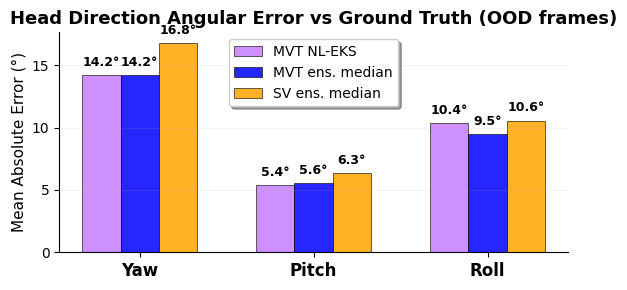

In [33]:
if len(ood_angular_df) > 0:
    angle_order = ['Yaw', 'Pitch', 'Roll']
    model_order = ['MVT NL-EKS','MVT ens. median', 'SV ens. median']
    model_colors = {'MVT ens. median': 'blue', 'MVT NL-EKS': '#C77DFF', 'SV ens. median': 'orange'}

    agg = ood_angular_df.groupby(['model', 'angle'])['mae_deg'].agg(['mean', 'std']).reset_index()

    fig, ax = plt.subplots(figsize=(6, 3))
    x = np.arange(len(angle_order))
    bw = 0.22

    for mi, model in enumerate(model_order):
        vals = []
        for angle in angle_order:
            row = agg[(agg['model'] == model) & (agg['angle'] == angle)]
            vals.append(row['mean'].values[0] if len(row) > 0 else 0)
        offset = (mi - 1) * bw
        bars = ax.bar(x + offset, vals, bw, label=model,
                       color=model_colors[model], alpha=0.85,
                       edgecolor='black', linewidth=0.5)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{val:.1f}°', ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(angle_order, fontsize=12, fontweight='bold')
    ax.set_ylabel('Mean Absolute Error (°)', fontsize=11)
    ax.set_title('Head Direction Angular Error vs Ground Truth (OOD frames)',
                 fontsize=13, fontweight='bold')
    ax.legend(fontsize=10, frameon=True, fancybox=True, shadow=True)
    ax.grid(alpha=0.15, axis='y')
    ax.set_ylim(bottom=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    fig.tight_layout()
    save_path = '/teamspace/studios/this_studio/outputs/chickadee-crop/plots/head_direction_plots/ood_angular_error.pdf'
    fig.savefig(save_path, bbox_inches='tight', dpi=300)
    plt.show()
else:
    print('No OOD angular error data available.')

In [34]:
if len(ood_angular_df) > 0:
    print('Mean Absolute Angular Error vs Ground Truth (degrees)')
    print('=' * 60)
    print(f'{"Model":<22s} {"Yaw":>8s} {"Pitch":>8s} {"Roll":>8s}')
    print('-' * 60)
    for model in ['MVT ens. median', 'MVT NL-EKS', 'SV ens. median']:
        vals = []
        for angle in ['Yaw', 'Pitch', 'Roll']:
            sub = ood_angular_df[(ood_angular_df['model'] == model) & (ood_angular_df['angle'] == angle)]
            vals.append(f'{sub["mae_deg"].mean():.2f}°')
        print(f'{model:<22s} {vals[0]:>8s} {vals[1]:>8s} {vals[2]:>8s}')
    n_frames = ood_angular_df.groupby('session')['n_frames'].first().sum()
    print(f'\nTotal OOD frames evaluated: {n_frames}')

Mean Absolute Angular Error vs Ground Truth (degrees)
Model                       Yaw    Pitch     Roll
------------------------------------------------------------
MVT ens. median          14.22°    5.56°    9.46°
MVT NL-EKS               14.19°    5.41°   10.37°
SV ens. median           16.81°    6.33°   10.57°

Total OOD frames evaluated: 142


## 13. Behavioral Analysis — Model Comparison

Behavioral metrics that reveal how model quality affects downstream
ethological analysis. A better pose model should produce:
- Cleaner separation between fixations and saccades in the velocity distribution
- Lower angular jitter during fixation periods
- Sharper, more stereotyped saccade waveforms
- Crisper polar gaze-direction histograms

### 13a. Angular Velocity Distribution

Chickadees alternate between stable **fixations** (near-zero velocity) and
rapid **saccades** (high velocity). A good model should produce a distribution
with a sharp peak near 0 and a clearly separated saccadic tail.
A noisy model blurs these two modes together.

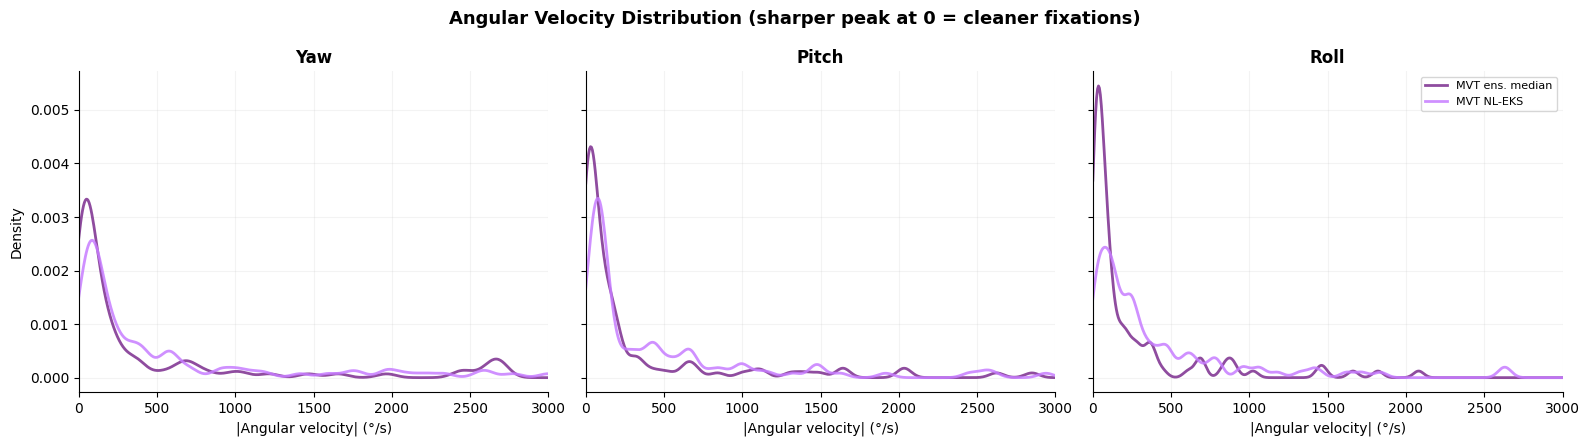

In [35]:
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
angle_names = ['yaw', 'pitch', 'roll']
vel_cap = 3000  # cap x-axis at this value for readability

for ax, aname in zip(axes, angle_names):
    for model in angles:
        trace = angles[model][aname]
        vel = np.abs(np.gradient(trace, dt))
        vel = vel[vel < vel_cap]
        kde = gaussian_kde(vel, bw_method=0.08)
        xs = np.linspace(0, vel_cap, 500)
        ax.plot(xs, kde(xs), label=model, color=plot_colors.get(model, None),
                linewidth=2, alpha=0.85)
    ax.set_xlabel('|Angular velocity| (°/s)', fontsize=10)
    ax.set_title(aname.capitalize(), fontsize=12, fontweight='bold')
    ax.set_xlim(0, vel_cap)
    ax.grid(alpha=0.15)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].set_ylabel('Density', fontsize=10)
axes[-1].legend(fontsize=8, frameon=True, loc='upper right')
fig.suptitle('Angular Velocity Distribution (sharper peak at 0 = cleaner fixations)',
             fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

### 13b. Fixation Stability

During fixation periods (between saccades), the bird's head is stationary.
A better model should show **lower angular jitter** (standard deviation)
during these periods. High jitter means the model is injecting noise
into what should be a still signal.

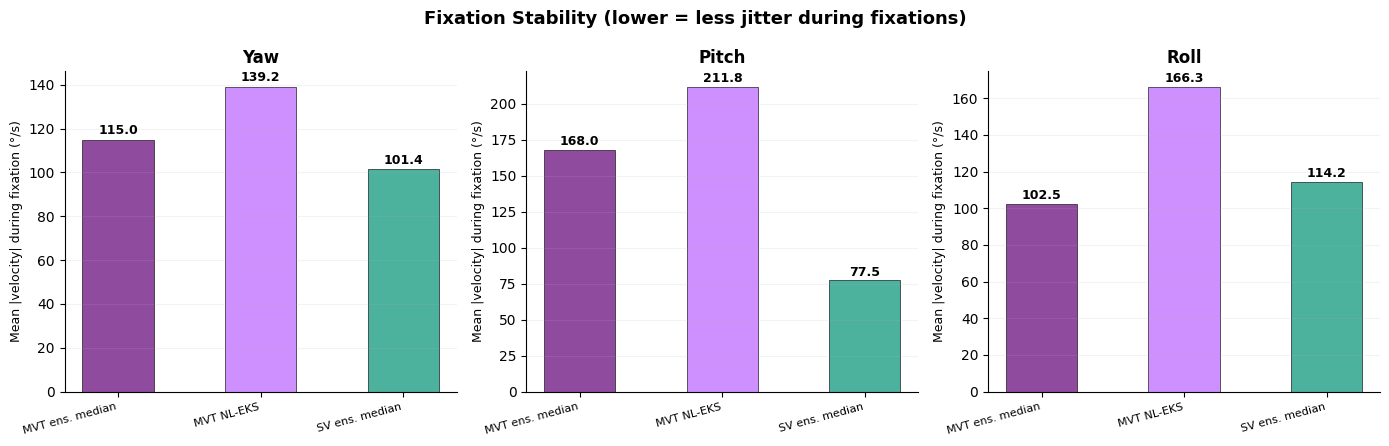

Fixation Stability Summary
Model                       Yaw    Pitch     Roll      Fix %
----------------------------------------------------------------------
MVT ens. median          115.0°/s  168.0°/s  102.5°/s     73.0%
MVT NL-EKS               139.2°/s  211.8°/s  166.3°/s     57.0%
SV ens. median           101.4°/s   77.5°/s  114.2°/s     68.0%


In [33]:
fixation_stats = {}
for model in angles:
    mask = saccade_results[model]['is_saccade']
    fix_mask = ~mask
    stats = {}
    for aname in ['yaw', 'pitch', 'roll']:
        trace = angles[model][aname]
        vel = np.abs(np.gradient(trace, dt))
        fix_vel = vel[fix_mask]
        fix_std = np.std(trace[fix_mask] - np.mean(trace[fix_mask]))
        stats[aname] = {
            'std_deg': fix_std,
            'mean_vel': np.mean(fix_vel),
            'median_vel': np.median(fix_vel),
            'pct_fixation': fix_mask.sum() / len(fix_mask) * 100,
        }
    fixation_stats[model] = stats

# Bar plot
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=False)
angle_names = ['yaw', 'pitch', 'roll']
models = list(angles.keys())
x = np.arange(len(models))
bw = 0.5

for ax, aname in zip(axes, angle_names):
    vals = [fixation_stats[m][aname]['mean_vel'] for m in models]
    cols = [plot_colors.get(m, 'gray') for m in models]
    bars = ax.bar(x, vals, bw, color=cols, alpha=0.85,
                  edgecolor='black', linewidth=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                '%.1f' % val, ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=8, rotation=15, ha='right')
    ax.set_title(aname.capitalize(), fontsize=12, fontweight='bold')
    ax.set_ylabel('Mean |velocity| during fixation (°/s)', fontsize=9)
    ax.grid(alpha=0.15, axis='y')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylim(bottom=0)

fig.suptitle('Fixation Stability (lower = less jitter during fixations)',
             fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

# Print table
print('Fixation Stability Summary')
print('=' * 70)
print('%-22s %8s %8s %8s %10s' % ('Model', 'Yaw', 'Pitch', 'Roll', 'Fix %'))
print('-' * 70)
for m in models:
    s = fixation_stats[m]
    print('%-22s %7.1f°/s %6.1f°/s %6.1f°/s %8.1f%%' % (
        m, s['yaw']['mean_vel'], s['pitch']['mean_vel'],
        s['roll']['mean_vel'], s['yaw']['pct_fixation']))

### 13c. Saccade-Triggered Average

Align all detected saccades at their onset and average the yaw trajectory.
A better model produces a **sharper, more stereotyped** waveform with
tighter confidence bands, because the underlying saccade dynamics are
real and repeatable — noise washes out in the average.

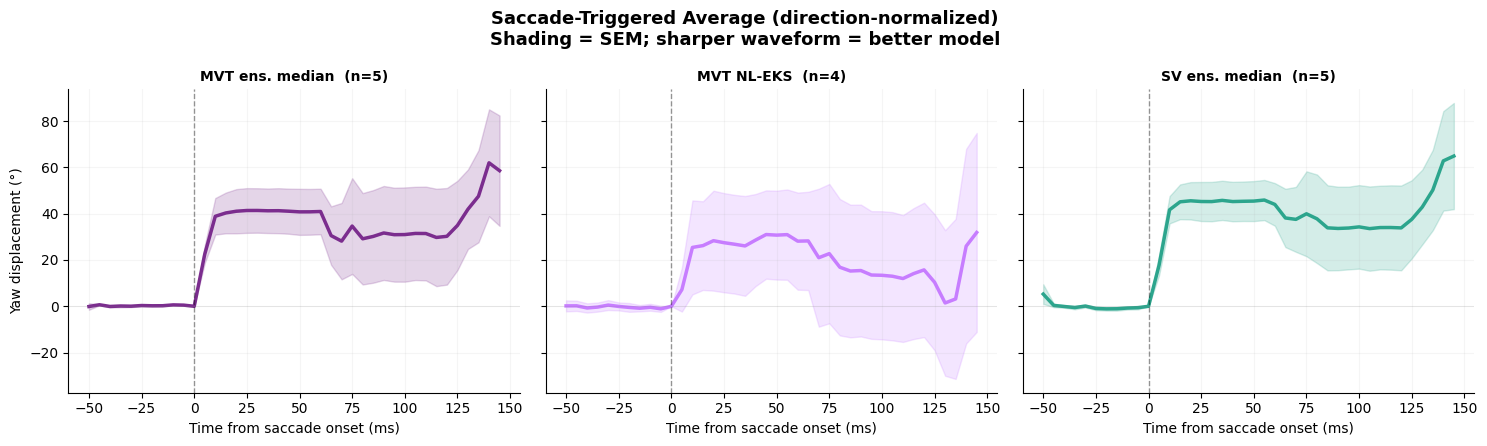

In [34]:
window_before_ms = 50
window_after_ms = 150
wb = int(window_before_ms / 1000 * fps)
wa = int(window_after_ms / 1000 * fps)

fig, axes = plt.subplots(1, len(angles), figsize=(5 * len(angles), 4.5), sharey=True)
if len(angles) == 1:
    axes = [axes]

for ax, model in zip(axes, angles):
    sacc_list = saccade_results[model]['saccades']
    yaw = angles[model]['yaw']
    snippets = []
    for s in sacc_list:
        onset = s['onset']
        lo, hi = onset - wb, onset + wa
        if lo < 0 or hi > len(yaw):
            continue
        snippet = yaw[lo:hi] - yaw[onset]
        if s['direction'] == 'CCW':
            snippet = -snippet
        snippets.append(snippet)
    if len(snippets) == 0:
        ax.set_title('%s\n(no saccades)' % model, fontsize=10)
        continue
    snippets = np.array(snippets)
    t_ms = np.arange(-wb, wa) * dt * 1000
    mean_s = np.nanmean(snippets, axis=0)
    sem_s = np.nanstd(snippets, axis=0) / np.sqrt(len(snippets))
    col = plot_colors.get(model, 'gray')
    ax.plot(t_ms, mean_s, color=col, linewidth=2.5)
    ax.fill_between(t_ms, mean_s - sem_s, mean_s + sem_s, color=col, alpha=0.2)
    ax.axvline(0, color='black', linestyle='--', alpha=0.4, linewidth=1)
    ax.axhline(0, color='gray', linestyle='-', alpha=0.2, linewidth=0.5)
    ax.set_xlabel('Time from saccade onset (ms)', fontsize=10)
    ax.set_title('%s  (n=%d)' % (model, len(snippets)), fontsize=10, fontweight='bold')
    ax.grid(alpha=0.12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].set_ylabel('Yaw displacement (°)', fontsize=10)
fig.suptitle('Saccade-Triggered Average (direction-normalized)\n'
             'Shading = SEM; sharper waveform = better model',
             fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

### 13d. Saccade-Triggered Average — All Models Overlaid

Same data as above but overlaid on a single axis for direct comparison.

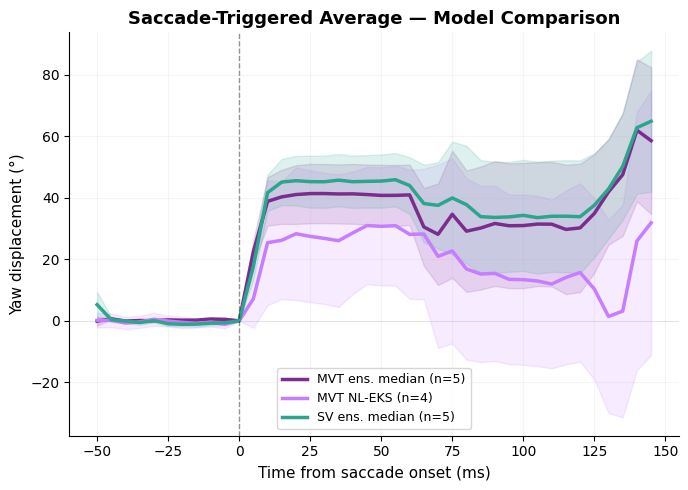

In [35]:
fig, ax = plt.subplots(figsize=(7, 5))

for model in angles:
    sacc_list = saccade_results[model]['saccades']
    yaw = angles[model]['yaw']
    snippets = []
    for s in sacc_list:
        onset = s['onset']
        lo, hi = onset - wb, onset + wa
        if lo < 0 or hi > len(yaw):
            continue
        snippet = yaw[lo:hi] - yaw[onset]
        if s['direction'] == 'CCW':
            snippet = -snippet
        snippets.append(snippet)
    if len(snippets) == 0:
        continue
    snippets = np.array(snippets)
    t_ms = np.arange(-wb, wa) * dt * 1000
    mean_s = np.nanmean(snippets, axis=0)
    sem_s = np.nanstd(snippets, axis=0) / np.sqrt(len(snippets))
    col = plot_colors.get(model, 'gray')
    ax.plot(t_ms, mean_s, color=col, linewidth=2.5, label='%s (n=%d)' % (model, len(snippets)))
    ax.fill_between(t_ms, mean_s - sem_s, mean_s + sem_s, color=col, alpha=0.15)

ax.axvline(0, color='black', linestyle='--', alpha=0.4, linewidth=1)
ax.axhline(0, color='gray', linestyle='-', alpha=0.2, linewidth=0.5)
ax.set_xlabel('Time from saccade onset (ms)', fontsize=11)
ax.set_ylabel('Yaw displacement (°)', fontsize=11)
ax.set_title('Saccade-Triggered Average — Model Comparison', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, frameon=True, fancybox=True)
ax.grid(alpha=0.12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.tight_layout()
plt.show()

### 13e. Polar Head Direction Distribution

Polar histogram of yaw angle showing the bird's preferred gaze directions.
A noisier model produces a more diffuse (uniform) distribution;
a better model reveals sharper directional preferences.

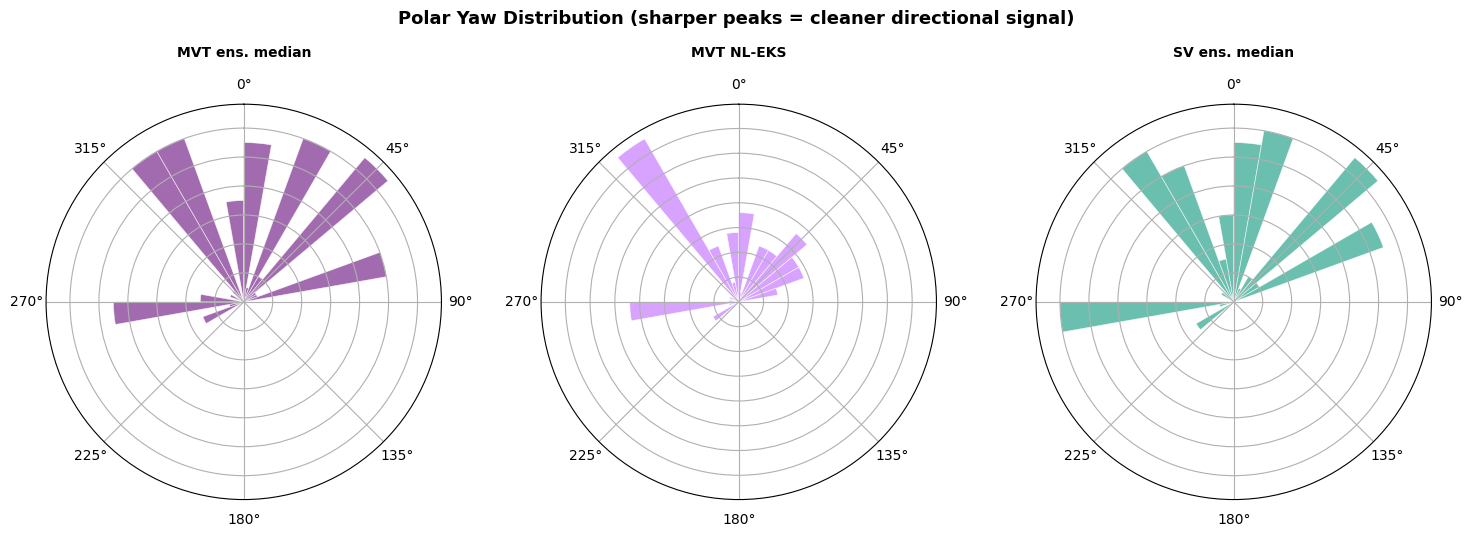

In [36]:
n_bins = 36
bin_edges = np.linspace(-np.pi, np.pi, n_bins + 1)

fig, axes = plt.subplots(1, len(angles), figsize=(5 * len(angles), 5),
                          subplot_kw={'projection': 'polar'})
if len(angles) == 1:
    axes = [axes]

for ax, model in zip(axes, angles):
    yaw_rad = np.radians(angles[model]['yaw'])
    counts, _ = np.histogram(yaw_rad, bins=bin_edges)
    counts = counts / counts.sum()
    widths = np.diff(bin_edges)
    centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    col = plot_colors.get(model, 'gray')
    ax.bar(centers, counts, width=widths, color=col, alpha=0.7,
           edgecolor='white', linewidth=0.5)
    ax.set_title(model, fontsize=10, fontweight='bold', pad=15)
    ax.set_yticklabels([])
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)

fig.suptitle('Polar Yaw Distribution (sharper peaks = cleaner directional signal)',
             fontsize=13, fontweight='bold', y=1.02)
fig.tight_layout()
plt.show()

### 13f. Head Direction Close-Up (1-second window)

A short time window showing all models overlaid on the same axes.
Smooth agreement during fixations and sharp transitions during saccades
indicate high-quality tracking.

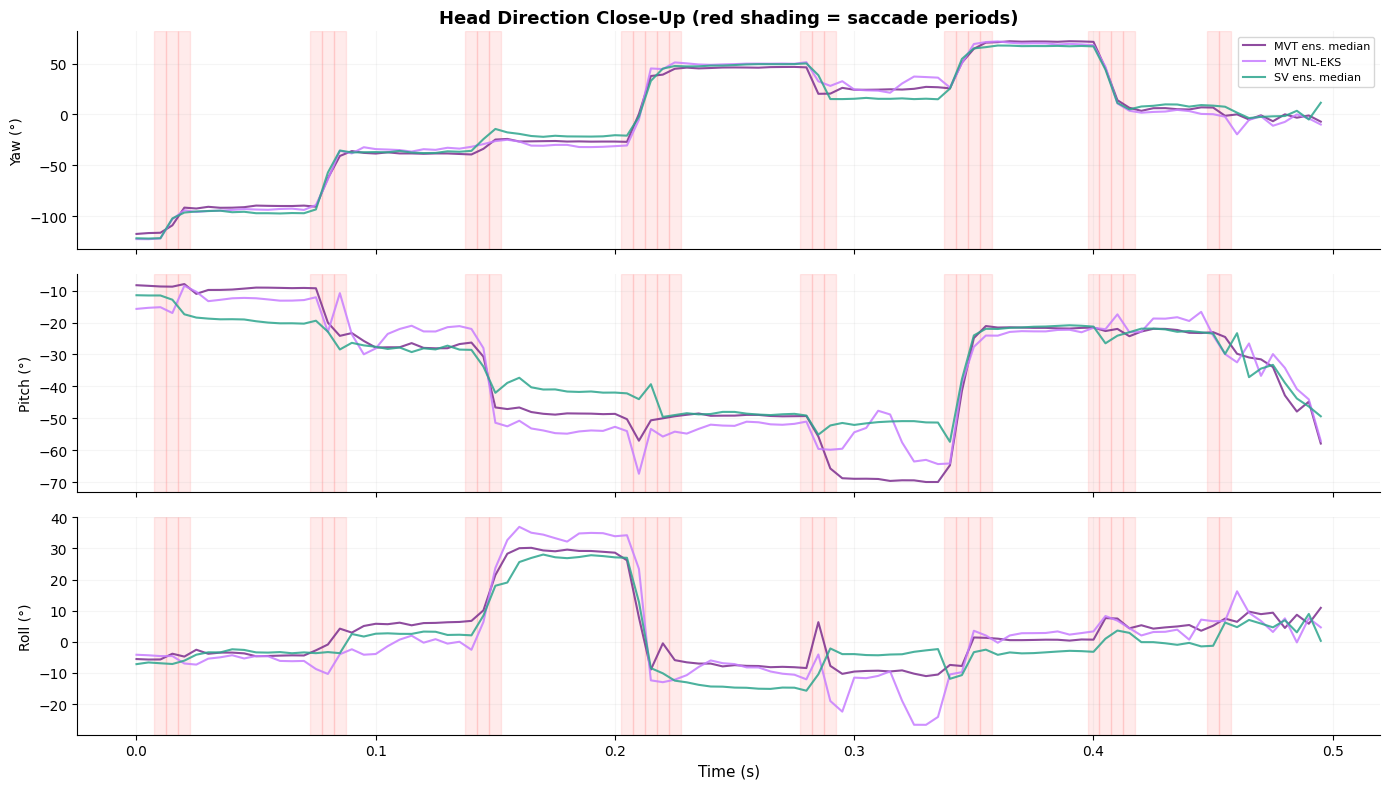

In [37]:
# Pick a 1-second window centered on the first detected saccade
ref_saccades = saccade_results[reference_model]['saccades']
if len(ref_saccades) > 0:
    center_frame = ref_saccades[0]['onset']
else:
    center_frame = len(angles[reference_model]['yaw']) // 2

half_win = int(0.5 * fps)
f0 = max(0, center_frame - half_win)
f1 = min(len(angles[reference_model]['yaw']), center_frame + half_win)
t_sec = np.arange(f0, f1) / fps

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

for ax, aname in zip(axes, ['yaw', 'pitch', 'roll']):
    for model in angles:
        col = plot_colors.get(model, None)
        ax.plot(t_sec, angles[model][aname][f0:f1], label=model,
                color=col, linewidth=1.5, alpha=0.85)
    # Shade saccade regions from reference model
    mask = saccade_results[reference_model]['is_saccade'][f0:f1]
    for i in range(len(mask)):
        if mask[i]:
            ax.axvspan(t_sec[i] - 0.5/fps, t_sec[i] + 0.5/fps,
                       color='red', alpha=0.08)
    ax.set_ylabel('%s (°)' % aname.capitalize(), fontsize=10)
    ax.grid(alpha=0.12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].legend(fontsize=8, frameon=True, loc='upper right')
axes[0].set_title('Head Direction Close-Up (red shading = saccade periods)',
                  fontsize=13, fontweight='bold')
axes[-1].set_xlabel('Time (s)', fontsize=11)
fig.tight_layout()
plt.show()

## 14. 3D Rigid Body Consistency (OOD data, all sessions)

The bird's head is a **rigid body**: distances between anatomical landmarks
(e.g. left eye ↔ right eye, beak ↔ back of head) must remain constant.
Any variation is **triangulation error**.

This analysis uses the **OOD hand-labeled frames** across all available
sessions, with per-session camera calibrations. Each model's predictions
are triangulated to 3D and inter-keypoint distances are measured.

A model with better multi-view 3D accuracy will produce more stable
inter-keypoint distances (lower coefficient of variation).

### 14a. Triangulate OOD frames and compute inter-keypoint distances

In [38]:
def compute_rigid_body_ood(data_dir, views, camera_params_dir, all_keypoints,
                           head_keys, base_output_dir, sv_results_dir,
                           sv_model_type, seed_dirs, kp_pairs):
    hidx = [all_keypoints.index(k) for k in head_keys]
    hkp_idx = {k: i for i, k in enumerate(head_keys)}

    gt_d, bbox_d = {}, {}
    for v in views:
        gt_d[v] = pd.read_csv(os.path.join(data_dir, f'CollectedData_{v}_new.csv'),
                               header=[0,1,2], index_col=0)
        bbox_d[v] = pd.read_csv(os.path.join(data_dir, f'bboxes_{v}_new.csv'), index_col=0)

    sf = {}
    for v in views:
        for idx in gt_d[v].index:
            parts = idx.split('/')
            sess = parts[1].replace(f'_{v}', '')
            fid = parts[2]
            sf.setdefault(sess, {}).setdefault(fid, set()).add(v)
    common = {}
    for sess, frames in sf.items():
        for fid, pv in frames.items():
            if len(pv) == len(views):
                common.setdefault(sess, []).append(fid)
    for s in common:
        common[s] = sorted(common[s])

    def _unc(xc, yc, br):
        return xc * (br['w'] / 320.0) + br['x'], yc * (br['h'] / 320.0) + br['y']

    def _tri_dicts(dd, bd, cg, sess, fids):
        p3, vl = [], []
        for fid in fids:
            p2 = []
            for v in views:
                fi = f'labeled-data/{sess}_{v}/{fid}'
                if fi not in dd[v].index or fi not in bd[v].index:
                    p2.append(np.full((len(all_keypoints), 2), np.nan))
                    continue
                row = dd[v].loc[fi]
                xc = np.array([row.xs(k, level=1).xs('x', level=1).values[0] for k in all_keypoints])
                yc = np.array([row.xs(k, level=1).xs('y', level=1).values[0] for k in all_keypoints])
                xo, yo = _unc(xc, yc, bd[v].loc[fi])
                p2.append(np.column_stack([xo, yo]))
            p2 = np.stack(p2)
            p2c = p2.copy()
            p2c[np.isnan(p2c)] = 0
            try:
                p3.append(cg.triangulate(p2c, fast=True))
                vl.append(fid)
            except:
                pass
        return (np.stack(p3), vl) if p3 else (np.empty((0, len(all_keypoints), 3)), [])

    def _tri_pf(mdir, bd, cg, sess, fids, uncropped=False):
        p3, vl = [], []
        for fid in fids:
            p2 = []
            for v in views:
                vd = os.path.join(mdir, 'videos-for-each-labeled-frame', f'{sess}_{v}')
                stem = fid.replace('.png', '')
                fp = os.path.join(vd, stem + ('_uncropped.csv' if uncropped else '.csv'))
                if not os.path.exists(fp):
                    p2.append(np.full((len(all_keypoints), 2), np.nan))
                    continue
                df = pd.read_csv(fp, header=[0,1,2], index_col=0)
                if len(df) == 0:
                    p2.append(np.full((len(all_keypoints), 2), np.nan))
                    continue
                row = df.iloc[len(df) // 2]
                xs, ys = [], []
                for k in all_keypoints:
                    try:
                        xs.append(row.xs(k, level=1).xs('x', level=1).values[0])
                        ys.append(row.xs(k, level=1).xs('y', level=1).values[0])
                    except:
                        xs.append(np.nan)
                        ys.append(np.nan)
                xa, ya = np.array(xs, dtype=float), np.array(ys, dtype=float)
                if not uncropped:
                    fi2 = f'labeled-data/{sess}_{v}/{fid}'
                    if fi2 in bd[v].index:
                        xa, ya = _unc(xa, ya, bd[v].loc[fi2])
                    else:
                        p2.append(np.full((len(all_keypoints), 2), np.nan))
                        continue
                p2.append(np.column_stack([xa, ya]))
            p2 = np.stack(p2)
            p2c = p2.copy()
            p2c[np.isnan(p2c)] = 0
            try:
                p3.append(cg.triangulate(p2c, fast=True))
                vl.append(fid)
            except:
                pass
        return (np.stack(p3), vl) if p3 else (np.empty((0, len(all_keypoints), 3)), [])

    mvt_ens_dir = os.path.join(base_output_dir, 'ensemble_median')
    mvt_eks_dir = os.path.join(base_output_dir, 'non_linear_eks_varinf')

    model_cfgs = {
        'MVT ens. median': ('per_frame', mvt_ens_dir, False),
        'MVT NL-EKS': ('per_frame', mvt_eks_dir, True),
        'SV ens. median': ('seed_median', sv_results_dir, sv_model_type),
    }

    all_results = []
    for sess, fids in common.items():
        cp = os.path.join(camera_params_dir, f'{sess}.toml')
        if not os.path.exists(cp):
            continue
        cg = CameraGroup.load(cp)

        gt_3d, vf = _tri_dicts(gt_d, bbox_d, cg, sess, fids)
        if gt_3d.shape[0] == 0:
            continue
        print(f'  {sess}: {gt_3d.shape[0]} OOD frames')

        for mn, cfg in model_cfgs.items():
            p3 = None
            if cfg[0] == 'per_frame':
                p3, _ = _tri_pf(cfg[1], bbox_d, cg, sess, vf, cfg[2])
            elif cfg[0] == 'seed_median':
                s3s = []
                for sd in seed_dirs:
                    dd = {}
                    for v in views:
                        pp = os.path.join(cfg[1], f'{cfg[2]}_200_{sd}',
                                          'image_preds', f'CollectedData_{v}_new.csv',
                                          'predictions.csv')
                        if os.path.exists(pp):
                            dd[v] = pd.read_csv(pp, header=[0,1,2], index_col=0)
                    if len(dd) < len(views):
                        continue
                    s, _ = _tri_dicts(dd, bbox_d, cg, sess, vf)
                    if s.shape[0] > 0:
                        s3s.append(s)
                if len(s3s) == len(seed_dirs):
                    p3 = np.median(np.stack(s3s), axis=0)

            if p3 is None or p3.shape[0] == 0:
                continue

            head_3d = p3[:, hidx, :]
            for kp_a, kp_b, label in kp_pairs:
                ia, ib = hkp_idx[kp_a], hkp_idx[kp_b]
                dists = np.linalg.norm(head_3d[:, ia, :] - head_3d[:, ib, :], axis=1) * 1000
                for fi, d in enumerate(dists):
                    all_results.append({
                        'session': sess, 'model': mn, 'pair': label,
                        'distance_mm': d, 'frame_idx': fi,
                    })

            # Also compute GT distances for reference
            gt_head = gt_3d[:, hidx, :]
            n = min(gt_head.shape[0], head_3d.shape[0])
            for kp_a, kp_b, label in kp_pairs:
                ia, ib = hkp_idx[kp_a], hkp_idx[kp_b]
                dists = np.linalg.norm(gt_head[:n, ia, :] - gt_head[:n, ib, :], axis=1) * 1000
                for fi, d in enumerate(dists):
                    all_results.append({
                        'session': sess, 'model': 'Ground Truth', 'pair': label,
                        'distance_mm': d, 'frame_idx': fi,
                    })

    return pd.DataFrame(all_results)

kp_pairs_rigid = [
    ('leftEye', 'rightEye', 'Eye-to-Eye'),
    ('topBeak', 'botBeak', 'Top-Bot Beak'),
    ('topBeak', 'backHead', 'Beak-BackHead'),
    ('leftEye', 'topBeak', 'LeftEye-Beak'),
    ('rightEye', 'topBeak', 'RightEye-Beak'),
    ('leftEye', 'backHead', 'LeftEye-BackHead'),
]

In [39]:
mvt_ens_base = os.path.join(
    '/teamspace/studios/this_studio/outputs/chickadee-crop',
    'test_200_MVT_3d_loss_patch_masking_new', 'mvt_3d_loss_200_0-2')

rigid_df = compute_rigid_body_ood(
    data_dir=f'/teamspace/studios/data/{dataset_name}',
    views=views,
    camera_params_dir=camera_params_dir,
    all_keypoints=ALL_KEYPOINTS,
    head_keys=HEAD_KEYS,
    base_output_dir=mvt_ens_base,
    sv_results_dir=os.path.join('/teamspace/studios/this_studio/outputs/chickadee-crop', 'test_200_SV_vits_dino'),
    sv_model_type='supervised',
    seed_dirs=seed_dirs,
    kp_pairs=kp_pairs_rigid,
)
print(f'\nTotal rows: {len(rigid_df)}')
print(f'Sessions: {rigid_df["session"].nunique()}')
print(f'Models: {rigid_df["model"].unique().tolist()}')

  PRL43_200617_131904: 26 OOD frames


  PRL43_200701_142147: 27 OOD frames


  SLV151_200728_132004: 27 OOD frames


  SLV151_200730_131948: 62 OOD frames



Total rows: 5112
Sessions: 4
Models: ['MVT ens. median', 'Ground Truth', 'MVT NL-EKS', 'SV ens. median']


### 14b. Coefficient of Variation (CV) of Inter-Keypoint Distances

CV = std / mean (%). Lower CV means the distance is more stable across
OOD frames and sessions, indicating better rigid-body consistency.
Ground truth is included as a reference — it sets the floor for
how much CV is due to real anatomical variation vs. model error.

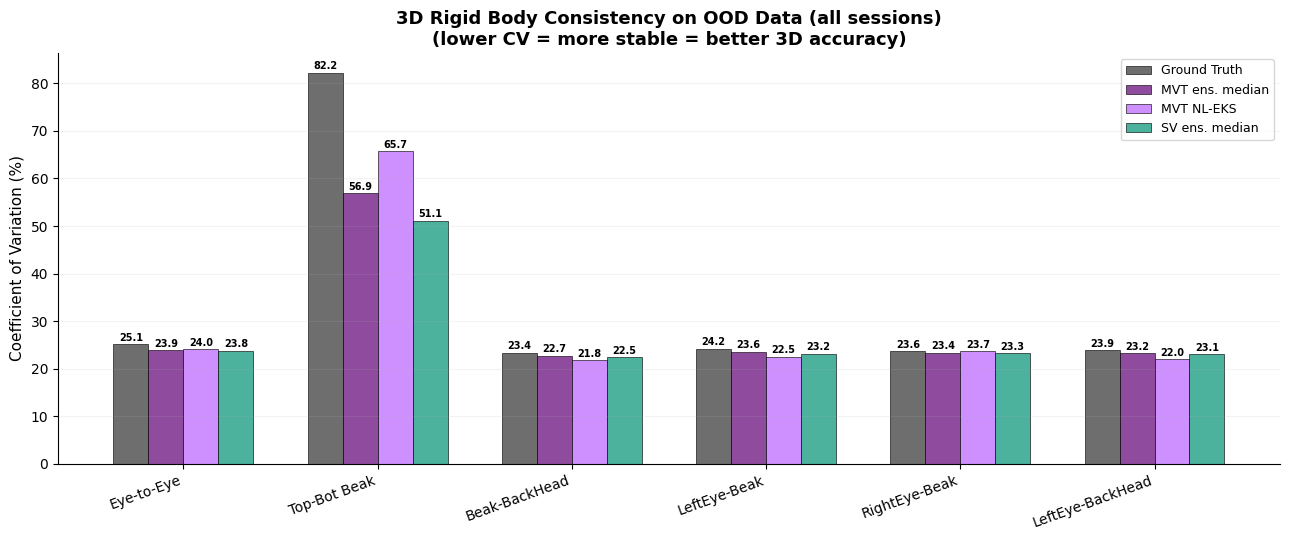

In [40]:
pair_labels = [p[2] for p in kp_pairs_rigid]
model_order = ['Ground Truth', 'MVT ens. median', 'MVT NL-EKS', 'SV ens. median']
model_colors_rigid = {
    'Ground Truth': '#555555',
    'MVT ens. median': '#7B2D8E',
    'MVT NL-EKS': '#C77DFF',
    'SV ens. median': '#2CA58D',
}

cv_data = {}
for model in model_order:
    cv_data[model] = {}
    for plabel in pair_labels:
        sub = rigid_df[(rigid_df['model'] == model) & (rigid_df['pair'] == plabel)]
        if len(sub) > 0:
            cv_data[model][plabel] = sub['distance_mm'].std() / sub['distance_mm'].mean() * 100
        else:
            cv_data[model][plabel] = np.nan

fig, ax = plt.subplots(figsize=(13, 5.5))
x = np.arange(len(pair_labels))
n_models = len(model_order)
bw = 0.18

for mi, model in enumerate(model_order):
    vals = [cv_data[model].get(p, 0) for p in pair_labels]
    offset = (mi - (n_models - 1) / 2) * bw
    bars = ax.bar(x + offset, vals, bw, label=model,
                  color=model_colors_rigid[model], alpha=0.85,
                  edgecolor='black', linewidth=0.5)
    for bar, val in zip(bars, vals):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    '%.1f' % val, ha='center', va='bottom', fontsize=7, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(pair_labels, fontsize=10, rotation=20, ha='right')
ax.set_ylabel('Coefficient of Variation (%)', fontsize=11)
ax.set_title('3D Rigid Body Consistency on OOD Data (all sessions)\n'
             '(lower CV = more stable = better 3D accuracy)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9, frameon=True, fancybox=True)
ax.grid(alpha=0.15, axis='y')
ax.set_ylim(bottom=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.tight_layout()
plt.show()

### 14c. Per-Session Rigid Body CV

Breaking down the CV by session shows whether the pattern is consistent
across different recordings and camera setups.

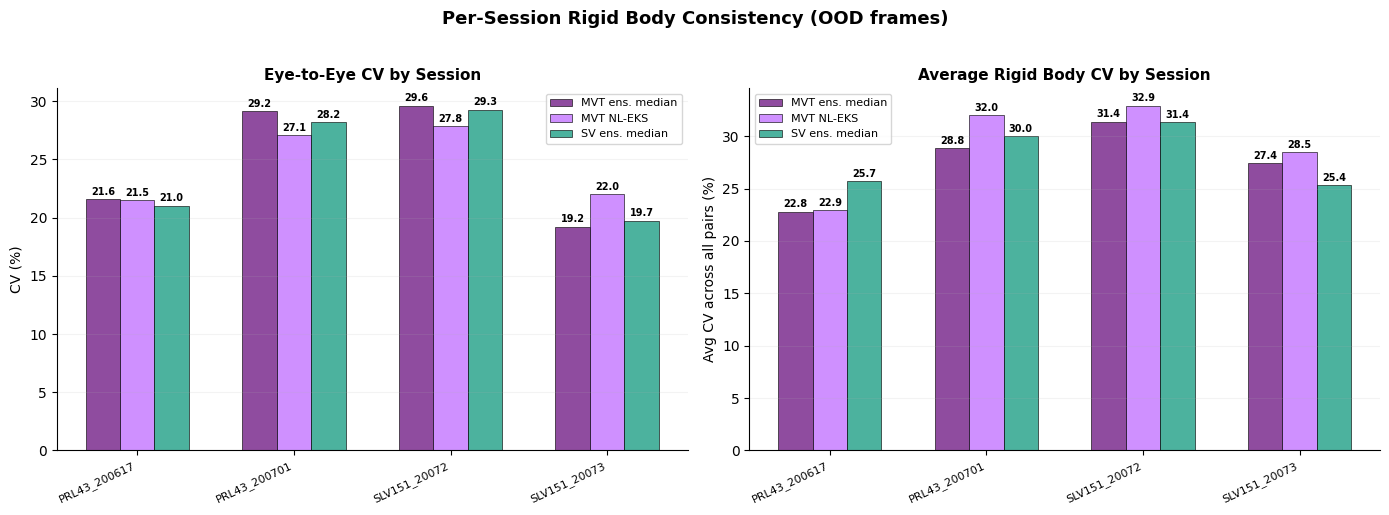

In [41]:
sessions = sorted(rigid_df['session'].unique())
model_order_no_gt = ['MVT ens. median', 'MVT NL-EKS', 'SV ens. median']
focus_pair = 'Eye-to-Eye'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: CV per session for Eye-to-Eye
ax = axes[0]
x = np.arange(len(sessions))
bw = 0.22
for mi, model in enumerate(model_order_no_gt):
    vals = []
    for sess in sessions:
        sub = rigid_df[(rigid_df['model'] == model) & (rigid_df['pair'] == focus_pair)
                       & (rigid_df['session'] == sess)]
        if len(sub) > 1:
            vals.append(sub['distance_mm'].std() / sub['distance_mm'].mean() * 100)
        else:
            vals.append(0)
    offset = (mi - 1) * bw
    bars = ax.bar(x + offset, vals, bw, label=model,
                  color=model_colors_rigid[model], alpha=0.85,
                  edgecolor='black', linewidth=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                '%.1f' % val, ha='center', va='bottom', fontsize=7, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([s[:12] for s in sessions], fontsize=8, rotation=25, ha='right')
ax.set_ylabel('CV (%)', fontsize=10)
ax.set_title(f'{focus_pair} CV by Session', fontsize=11, fontweight='bold')
ax.legend(fontsize=8, frameon=True)
ax.grid(alpha=0.15, axis='y')
ax.set_ylim(bottom=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Right: Average CV across all pairs per session
ax = axes[1]
for mi, model in enumerate(model_order_no_gt):
    vals = []
    for sess in sessions:
        sess_cvs = []
        for plabel in pair_labels:
            sub = rigid_df[(rigid_df['model'] == model) & (rigid_df['pair'] == plabel)
                           & (rigid_df['session'] == sess)]
            if len(sub) > 1:
                sess_cvs.append(sub['distance_mm'].std() / sub['distance_mm'].mean() * 100)
        vals.append(np.mean(sess_cvs) if sess_cvs else 0)
    offset = (mi - 1) * bw
    bars = ax.bar(x + offset, vals, bw, label=model,
                  color=model_colors_rigid[model], alpha=0.85,
                  edgecolor='black', linewidth=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                '%.1f' % val, ha='center', va='bottom', fontsize=7, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([s[:12] for s in sessions], fontsize=8, rotation=25, ha='right')
ax.set_ylabel('Avg CV across all pairs (%)', fontsize=10)
ax.set_title('Average Rigid Body CV by Session', fontsize=11, fontweight='bold')
ax.legend(fontsize=8, frameon=True)
ax.grid(alpha=0.15, axis='y')
ax.set_ylim(bottom=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.suptitle('Per-Session Rigid Body Consistency (OOD frames)',
             fontsize=13, fontweight='bold', y=1.02)
fig.tight_layout()
plt.show()

### 14d. Distribution of Inter-Keypoint Distances (OOD)

Violin plots showing the spread of each distance across all OOD frames
and sessions. Tighter violins = more consistent 3D reconstruction.
Ground truth included as reference.

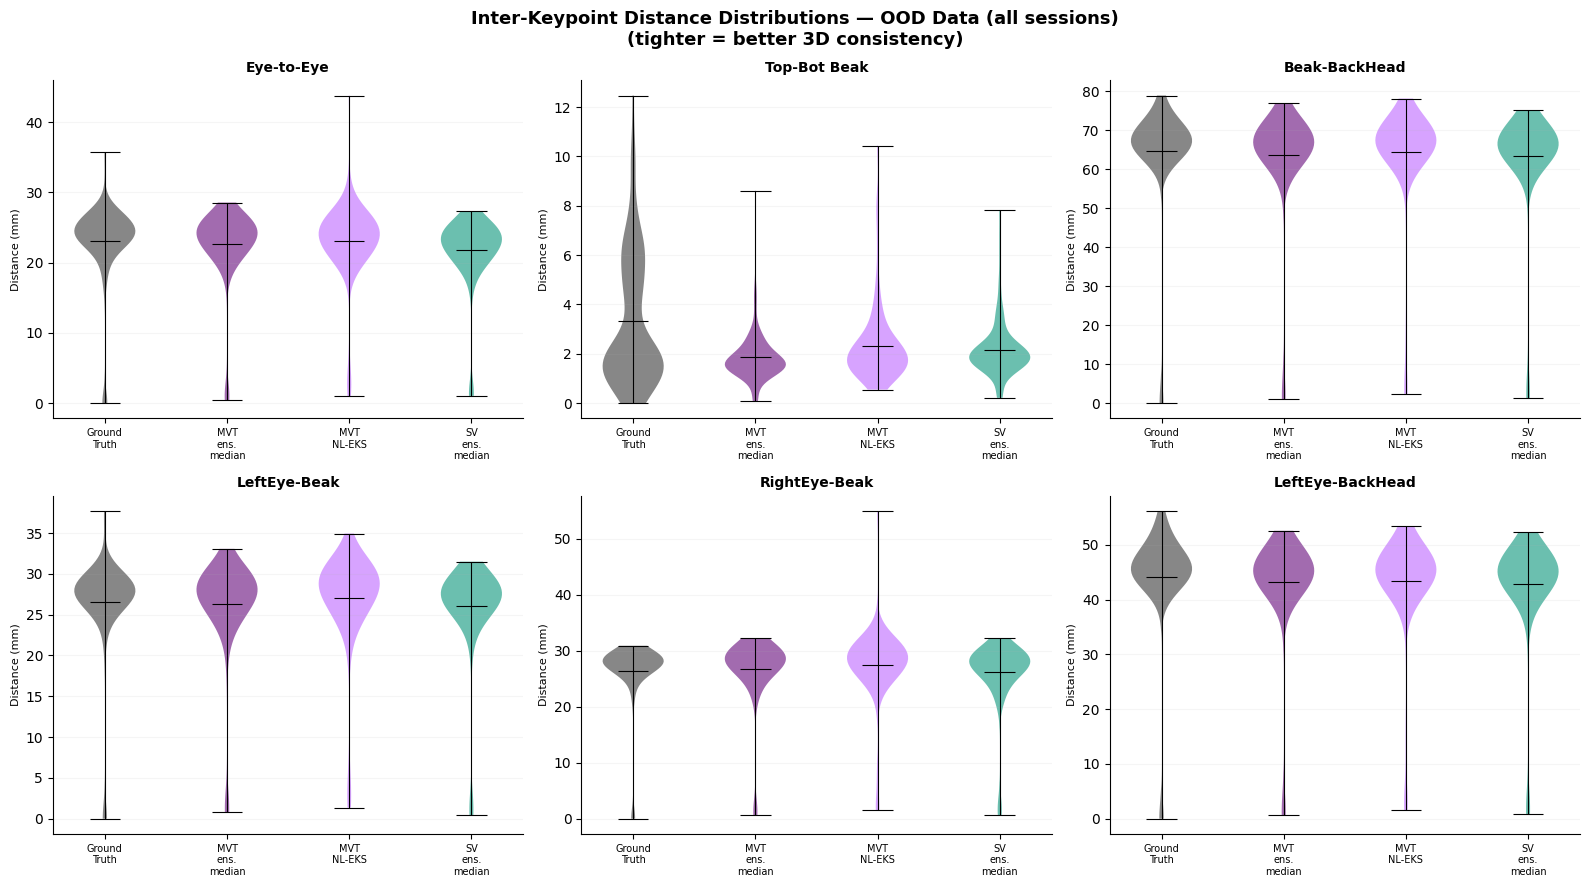

In [42]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for pi, plabel in enumerate(pair_labels):
    ax = axes[pi]
    data_list = []
    colors_list = []
    tick_labels = []
    for model in model_order:
        sub = rigid_df[(rigid_df['model'] == model) & (rigid_df['pair'] == plabel)]
        if len(sub) > 0:
            data_list.append(sub['distance_mm'].values)
            colors_list.append(model_colors_rigid[model])
            tick_labels.append(model)

    if len(data_list) == 0:
        continue
    parts = ax.violinplot(data_list, positions=range(len(data_list)),
                          showmeans=True, showmedians=False)
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(colors_list[i])
        pc.set_alpha(0.7)
    for partname in ['cmeans', 'cmins', 'cmaxes', 'cbars']:
        if partname in parts:
            parts[partname].set_edgecolor('black')
            parts[partname].set_linewidth(0.8)

    ax.set_xticks(range(len(tick_labels)))
    ax.set_xticklabels([m.replace(' ', '\n') for m in tick_labels], fontsize=7)
    ax.set_title(plabel, fontsize=10, fontweight='bold')
    ax.set_ylabel('Distance (mm)', fontsize=8)
    ax.grid(alpha=0.12, axis='y')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Inter-Keypoint Distance Distributions — OOD Data (all sessions)\n'
             '(tighter = better 3D consistency)',
             fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

In [43]:
print('Rigid Body Consistency Summary (OOD data, all sessions)')
print('=' * 80)
print('%-18s' % 'Pair', end='')
for m in model_order:
    print('  %18s' % m, end='')
print()
print('-' * 80)
for plabel in pair_labels:
    print('%-18s' % plabel, end='')
    for m in model_order:
        sub = rigid_df[(rigid_df['model'] == m) & (rigid_df['pair'] == plabel)]
        if len(sub) > 0:
            print('  %6.1f +/- %4.1f mm' % (sub['distance_mm'].mean(), sub['distance_mm'].std()), end='')
        else:
            print('  %18s' % 'N/A', end='')
    print()

print()
print('Average CV across all pairs:')
for m in model_order:
    cvs = [cv_data[m].get(p, np.nan) for p in pair_labels]
    avg_cv = np.nanmean(cvs)
    print('  %-22s: %.2f%%' % (m, avg_cv))

print()
n_sessions = rigid_df['session'].nunique()
n_frames = rigid_df[rigid_df['model'] == 'Ground Truth'].groupby('session')['frame_idx'].nunique().sum()
print(f'Total: {n_sessions} sessions, {n_frames} OOD frames')

Rigid Body Consistency Summary (OOD data, all sessions)
Pair                      Ground Truth     MVT ens. median          MVT NL-EKS      SV ens. median
--------------------------------------------------------------------------------
Eye-to-Eye            23.1 +/-  5.8 mm    22.7 +/-  5.4 mm    23.1 +/-  5.5 mm    21.8 +/-  5.2 mm
Top-Bot Beak           3.3 +/-  2.7 mm     1.9 +/-  1.1 mm     2.3 +/-  1.5 mm     2.1 +/-  1.1 mm
Beak-BackHead         64.5 +/- 15.1 mm    63.7 +/- 14.5 mm    64.4 +/- 14.0 mm    63.3 +/- 14.2 mm
LeftEye-Beak          26.5 +/-  6.4 mm    26.3 +/-  6.2 mm    27.0 +/-  6.1 mm    26.0 +/-  6.0 mm
RightEye-Beak         26.4 +/-  6.3 mm    26.8 +/-  6.3 mm    27.5 +/-  6.5 mm    26.2 +/-  6.1 mm
LeftEye-BackHead      44.2 +/- 10.6 mm    43.2 +/- 10.0 mm    43.5 +/-  9.6 mm    42.9 +/-  9.9 mm

Average CV across all pairs:
  Ground Truth          : 33.75%
  MVT ens. median       : 28.95%
  MVT NL-EKS            : 29.95%
  SV ens. median        : 27.82%

Total: 